# **Noise2Void (3D)**

---

<font size = 4> Noise2Void is a deep-learning method that can be used to denoise many types of images, including microscopy images and which was originally published by [Krull *et al.* on arXiv](https://arxiv.org/abs/1811.10980). It allows denoising of image data in a self-supervised manner, therefore high-quality, low noise equivalent images are not necessary to train this network. This is performed by "masking" a random subset of pixels in the noisy image and training the network to predict the values in these pixels. The resulting output is a denoised version of the image. Noise2Void is based on the popular U-Net network architecture, adapted from [CARE](https://www.nature.com/articles/s41592-018-0216-7).

<font size = 4> **This particular notebook enables self-supervised denoised of 3D dataset. If you are interested in 2D dataset, you should use the Noise2Void 2D notebook instead.**

---

<font size = 4>*Disclaimer*:

<font size = 4>This notebook is part of the Zero-Cost Deep-Learning to Enhance Microscopy project (https://github.com/HenriquesLab/DeepLearning_Collab/wiki). Jointly developed by the Jacquemet (link to https://cellmig.org/) and Henriques (https://henriqueslab.github.io/) laboratories.

<font size = 4>This notebook is largely based on the following paper:

<font size = 4>**Noise2Void - Learning Denoising from Single Noisy Images**
from Krull *et al.* published on arXiv in 2018 (https://arxiv.org/abs/1811.10980)

<font size = 4>And source code found in: https://github.com/juglab/n2v

<font size = 4>**Please also cite this original paper when using or developing this notebook.**



# **How to use this notebook?**

---

<font size = 4>Video describing how to use our notebooks are available on youtube:
  - [**Video 1**](https://www.youtube.com/watch?v=GzD2gamVNHI&feature=youtu.be): Full run through of the workflow to obtain the notebooks and the provided test datasets as well as a common use of the notebook
  - [**Video 2**](https://www.youtube.com/watch?v=PUuQfP5SsqM&feature=youtu.be): Detailed description of the different sections of the notebook


---


### **Structure of a notebook**

<font size = 4>The notebook contains two types of cell:  

<font size = 4>**Text cells** provide information and can be modified by douple-clicking the cell. You are currently reading the text cell. You can create a new text by clicking `+ Text`.

<font size = 4>**Code cells** contain code and the code can be modfied by selecting the cell. To execute the cell, move your cursor on the `[ ]`-mark on the left side of the cell (play button appears). Click to execute the cell. After execution is done the animation of play button stops. You can create a new coding cell by clicking `+ Code`.

---
### **Table of contents, Code snippets** and **Files**

<font size = 4>On the top left side of the notebook you find three tabs which contain from top to bottom:

<font size = 4>*Table of contents* = contains structure of the notebook. Click the content to move quickly between sections.

<font size = 4>*Code snippets* = contain examples how to code certain tasks. You can ignore this when using this notebook.

<font size = 4>*Files* = contain all available files. After mounting your google drive (see section 1.) you will find your files and folders here. 

<font size = 4>**Remember that all uploaded files are purged after changing the runtime.** All files saved in Google Drive will remain. You do not need to use the Mount Drive-button; your Google Drive is connected in section 1.2.

<font size = 4>**Note:** The "sample data" in "Files" contains default files. Do not upload anything in here!

---
### **Making changes to the notebook**

<font size = 4>**You can make a copy** of the notebook and save it to your Google Drive. To do this click file -> save a copy in drive.

<font size = 4>To **edit a cell**, double click on the text. This will show you either the source code (in code cells) or the source text (in text cells).
You can use the `#`-mark in code cells to comment out parts of the code. This allows you to keep the original code piece in the cell as a comment.


# **0. Before getting started**
---

<font size = 4>Before you run the notebook, please ensure that you are logged into your Google account and have the training and/or data to process in your Google Drive.

<font size = 4>For Noise2Void to train, it only requires a single noisy image but multiple images can be used. Information on how to generate a training dataset is available in our Wiki page: https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki

<font size = 4>Please note that you currently can **only use .tif files!**

<font size = 4>**We strongly recommend that you generate high signal to noise ration version of your noisy images. These images can be used to assess the quality of your trained model (Quality control dataset)**. The quality control assessment can be done directly in this notebook.

<font size = 4> You can also provide a folder that contains the data that you wish to analyse with the trained network once all training has been performed.

<font size = 4>Here is a common data structure that can work:

*   Data
    - **Training dataset**
    - **Quality control dataset** (Optional but recomended)
     - Low SNR images
        - img_1.tif, img_2.tif
      - High SNR images
        - img_1.tif, img_2.tif     
    - **Data to be predicted** 
    - **Results**


<font size = 4>The **Results** folder will contain the processed images, trained model and network parameters as csv file. Your original images remain unmodified.

---
<font size = 4>**Important note**

<font size = 4>- If you wish to **train a network from scratch** using your own dataset (and we encourage everyone to do that), you will need to run **sections 1 - 4**, then use **section 5** to assess the quality of your model and **section 6** to run predictions using the model that you trained.

<font size = 4>- If you wish to **evaluate your model** using a model previously generated and saved on your Google Drive, you will only need to run **sections 1 and 2** to set up the notebook, then use **section 5** to assess the quality of your model.

<font size = 4>- If you only wish to **run predictions** using a model previously generated and saved on your Google Drive, you will only need to run **sections 1 and 2** to set up the notebook, then use **section 6** to run the predictions on the desired model.
---



# **1. Install Noise2Void and dependencies**
---


## **1.1. Load key dependencies**
---
<font size = 4> 


In [1]:
# Run this cell to execute the code
from datetime import datetime
import ipywidgets as widgets
from IPython.display import Markdown, display, clear_output
from matplotlib import pyplot as plt
import yaml as yaml_library
import os

ipywidgets_edit_yaml_config_path = os.path.join(os.getcwd(), 'results', 'widget_prev_settings.yaml')

def ipywidgets_edit_yaml(yaml_path, key, value):
    if os.path.exists(yaml_path):
        with open(yaml_path, 'r') as f:
            config_data = yaml_library.safe_load(f)
    else:
        config_data = {}
    config_data[key] = value
    with open(yaml_path, 'w') as new_f:
        yaml_library.safe_dump(config_data, new_f, width=10e10, default_flow_style=False, allow_unicode=True)

def ipywidgets_read_yaml(yaml_path, key):
    if os.path.exists(yaml_path):
        with open(yaml_path, 'r') as f:
            config_data = yaml_library.safe_load(f)
        value = config_data.get(key, '')
        return value
    else:
        return ''

internal_aux_initial_time=datetime.now()
print('Runnning...')
print('--------------------------------------')

Notebook_version = '1.16.2'
Network = 'Noise2Void (3D)'

from builtins import any as b_any

def get_requirements_path():
    # Store requirements file in 'contents' directory 
    current_dir = os.getcwd()
    dir_count = current_dir.count('/') - 1
    path = '../' * (dir_count) + 'requirements.txt'
    return path

def filter_files(file_list, filter_list):
    filtered_list = []
    for fname in file_list:
        if b_any(fname.split('==')[0] in s for s in filter_list):
            filtered_list.append(fname)
    return filtered_list

def build_requirements_file(before, after):
    path = get_requirements_path()

    # Exporting requirements.txt for local run
    !pip freeze > $path

    # Get minimum requirements file
    df = pd.read_csv(path)
    mod_list = [m.split('.')[0] for m in after if not m in before]
    req_list_temp = df.values.tolist()
    req_list = [x[0] for x in req_list_temp]

    # Replace with package name and handle cases where import name is different to module name
    mod_name_list = [['sklearn', 'scikit-learn'], ['skimage', 'scikit-image']]
    mod_replace_list = [[x[1] for x in mod_name_list] if s in [x[0] for x in mod_name_list] else s for s in mod_list] 
    filtered_list = filter_files(req_list, mod_replace_list)

    file=open(path,'w')
    for item in filtered_list:
        file.writelines(item)

    file.close()

import sys
before = [str(m) for m in sys.modules]

import tensorflow
print('TensorFlow version:')
print(tensorflow.__version__)

print("Tensorflow enabled.")

%load_ext memory_profiler

# ------- Variable specific to N2V -------
from n2v.models import N2VConfig, N2V
from csbdeep.utils import plot_history
from n2v.utils.n2v_utils import manipulate_val_data
from n2v.internals.N2V_DataGenerator import N2V_DataGenerator
from csbdeep.io import save_tiff_imagej_compatible

# ------- Common variable to all ZeroCostDL4Mic notebooks -------
import numpy as np
from matplotlib import pyplot as plt
import urllib
import os, random
import shutil 
import zipfile
from tifffile import imread, imsave
import time
import sys
import wget
from pathlib import Path
import pandas as pd
import csv
from glob import glob
from scipy import signal
from scipy import ndimage
from skimage import io
from sklearn.linear_model import LinearRegression
from skimage.util import img_as_uint
import matplotlib as mpl
from skimage.metrics import structural_similarity
from skimage.metrics import peak_signal_noise_ratio as psnr
from astropy.visualization import simple_norm
from skimage import img_as_float32
from fpdf import FPDF, HTMLMixin
from datetime import datetime
from pip._internal.operations.freeze import freeze
import subprocess

#Create a variable to get and store relative base path
base_path = os.getcwd()

# Colors for the warning messages
class bcolors:
  WARNING = '\033[31m'
W  = '\033[0m'  # white (normal)
R  = '\033[31m' # red

#Disable some of the tensorflow warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries installed")

# Check if this is the latest version of the notebook
All_notebook_versions = pd.read_csv("https://raw.githubusercontent.com/HenriquesLab/ZeroCostDL4Mic/master/Colab_notebooks/Latest_Notebook_versions.csv", dtype=str)
print('Notebook version: '+Notebook_version)
Latest_Notebook_version = All_notebook_versions[All_notebook_versions["Notebook"] == Network]['Version'].iloc[0]
print('Latest notebook version: '+Latest_Notebook_version)
if Notebook_version == Latest_Notebook_version:
  print("This notebook is up-to-date.")
else:
  print(bcolors.WARNING +"A new version of this notebook has been released. We recommend that you download it at https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki")

def pdf_export(trained = False, augmentation = False, pretrained_model = False):
  class MyFPDF(FPDF, HTMLMixin):
    pass

  pdf = MyFPDF()
  pdf.add_page()
  pdf.set_right_margin(-1)
  pdf.set_font("Arial", size = 11, style='B') 

  Network = 'Noise2Void 3D'
  day = datetime.now()
  datetime_str = str(day)[0:10]

  Header = 'Training report for '+Network+' model ('+model_name+')\nDate: '+datetime_str
  pdf.multi_cell(180, 5, txt = Header, align = 'L') 
  pdf.ln(1)
    
  # add another cell 
  if trained:
    training_time = "Training time: "+str(hour)+ "hour(s) "+str(mins)+"min(s) "+str(round(sec))+"sec(s)"
    pdf.cell(190, 5, txt = training_time, ln = 1, align='L')
  pdf.ln(1)

  Header_2 = 'Information for your materials and method:'
  pdf.cell(190, 5, txt=Header_2, ln=1, align='L')

  all_packages = ''
  for requirement in freeze(local_only=True):
    all_packages = all_packages+requirement+', '
  #print(all_packages)

  #Main Packages
  main_packages = ''
  version_numbers = []
  for name in ['tensorflow','numpy','Keras','csbdeep']:
    find_name=all_packages.find(name)
    main_packages = main_packages+all_packages[find_name:all_packages.find(',',find_name)]+', '
    #Version numbers only here:
    version_numbers.append(all_packages[find_name+len(name)+2:all_packages.find(',',find_name)])

  try:
    cuda_version = subprocess.run(["nvcc","--version"],stdout=subprocess.PIPE)
    cuda_version = cuda_version.stdout.decode('utf-8')
    cuda_version = cuda_version[cuda_version.find(', V')+3:-1]
  except:
    cuda_version = ' - No cuda found - '
  try:
    gpu_name = subprocess.run(["nvidia-smi"],stdout=subprocess.PIPE)
    gpu_name = gpu_name.stdout.decode('utf-8')
    gpu_name = gpu_name[gpu_name.find('Tesla'):gpu_name.find('Tesla')+10]
  except:
    gpu_name = ' - No GPU found - '
  #print(cuda_version[cuda_version.find(', V')+3:-1])
  #print(gpu_name)

  shape = io.imread(Training_source+'/'+os.listdir(Training_source)[0]).shape
  dataset_size = len(os.listdir(Training_source))

  text = 'The '+Network+' model was trained from scratch for '+str(number_of_epochs)+' epochs on '+str(len(patches))+' image patches (image dimensions: '+str(shape)+', patch size: ('+str(patch_height)+','+str(patch_size)+','+str(patch_size)+')) with a batch size of '+str(batch_size)+' and a '+config.train_loss+' loss function, using the '+Network+' ZeroCostDL4Mic notebook (v '+Notebook_version[0]+') (von Chamier & Laine et al., 2020). Key python packages used include tensorflow (v '+version_numbers[0]+'), Keras (v '+version_numbers[2]+'), csbdeep (v '+version_numbers[3]+'), numpy (v '+version_numbers[1]+'), cuda (v '+cuda_version+'). The training was accelerated using a '+gpu_name+'GPU.'

  if pretrained_model:
    text = 'The '+Network+' model was trained for '+str(number_of_epochs)+' epochs on '+str(len(patches))+' paired image patches (image dimensions: '+str(shape)+', patch size: ('+str(patch_height)+','+str(patch_size)+','+str(patch_size)+')) with a batch size of '+str(batch_size)+' and a '+config.train_loss+' loss function, using the '+Network+' ZeroCostDL4Mic notebook (v '+Notebook_version[0]+') (von Chamier & Laine et al., 2020). The model was re-trained from a pretrained model. Key python packages used include tensorflow (v '+version_numbers[0]+'), Keras (v '+version_numbers[2]+'), csbdeep (v '+version_numbers[3]+'), numpy (v '+version_numbers[1]+'), cuda (v '+cuda_version+'). The training was accelerated using a '+gpu_name+'GPU.'

  pdf.set_font('')
  pdf.set_font_size(10.)
  pdf.multi_cell(190, 5, txt = text, align='L')
  pdf.ln(1)
  pdf.set_font('')
  pdf.set_font('Arial', size = 10, style = 'B')
  pdf.ln(1)
  pdf.cell(26, 5, txt='Augmentation: ', ln=0)
  pdf.set_font('')
  if augmentation:
    aug_text = 'The dataset was augmented by default.'
  else:
    aug_text = 'No augmentation was used for training.'
  pdf.multi_cell(190, 5, txt=aug_text, align='L')
  pdf.ln(1)
  pdf.set_font('Arial', size = 11, style = 'B')
  pdf.ln(1)
  pdf.cell(180, 5, txt = 'Parameters', align='L', ln=1)
  pdf.set_font('')
  pdf.set_font_size(10.)
  if Use_Default_Advanced_Parameters:
    pdf.cell(200, 5, txt='Default Advanced Parameters were enabled')
  pdf.cell(200, 5, txt='The following parameters were used for training:')
  pdf.ln(1)
  html = """ 
  <table width=40% style="margin-left:0px;">
    <tr>
      <th width = 50% align="left">Parameter</th>
      <th width = 50% align="left">Value</th>
    </tr>
    <tr>
      <td width = 50%>number_of_epochs</td>
      <td width = 50%>{0}</td>
    </tr>
    <tr>
      <td width = 50%>patch_size</td>
      <td width = 50%>{1}</td>
    </tr>
    <tr>
      <td width = 50%>batch_size</td>
      <td width = 50%>{2}</td>
    </tr>
    <tr>
      <td width = 50%>number_of_steps</td>
      <td width = 50%>{3}</td>
    </tr>
    <tr>
      <td width = 50%>percentage_validation</td>
      <td width = 50%>{4}</td>
    </tr>
    <tr>
      <td width = 50%>initial_learning_rate</td>
      <td width = 50%>{5}</td>
    </tr>
  </table>
  """.format(number_of_epochs,str(patch_height)+'x'+str(patch_size)+'x'+str(patch_size),batch_size,number_of_steps,percentage_validation,initial_learning_rate)
  pdf.write_html(html)

  #pdf.multi_cell(190, 5, txt = text_2, align='L')
  pdf.set_font("Arial", size = 11, style='B')
  pdf.ln(1)
  pdf.cell(190, 5, txt = 'Training Dataset', align='L', ln=1)
  pdf.set_font('')
  pdf.set_font('Arial', size = 10, style = 'B')
  pdf.cell(29, 5, txt= 'Training_source:', align = 'L', ln=0)
  pdf.set_font('')
  pdf.multi_cell(170, 5, txt = Training_source, align = 'L')
  pdf.ln(1)
  # pdf.set_font('')
  # pdf.set_font('Arial', size = 10, style = 'B')
  # pdf.cell(28, 5, txt= 'Training_target:', align = 'L', ln=0)
  # pdf.set_font('')
  # pdf.multi_cell(170, 5, txt = Training_target, align = 'L')
  #pdf.cell(190, 5, txt=aug_text, align='L', ln=1)
  pdf.ln(1)
  pdf.set_font('')
  pdf.set_font('Arial', size = 10, style = 'B')
  pdf.cell(21, 5, txt= 'Model Path:', align = 'L', ln=0)
  pdf.set_font('')
  pdf.multi_cell(170, 5, txt = model_path+'/'+model_name, align = 'L')
  pdf.ln(1)
  pdf.cell(60, 5, txt = 'Training Image', ln=1)
  pdf.ln(1)
  exp_size = io.imread(base_path + '/TrainingDataExample_N2V3D.png').shape
  pdf.image(base_path + '/TrainingDataExample_N2V3D.png', x = 11, y = None, w = round(exp_size[1]/8), h = round(exp_size[0]/8))
  pdf.ln(1)
  ref_1 = 'References:\n - ZeroCostDL4Mic: von Chamier, Lucas & Laine, Romain, et al. "Democratising deep learning for microscopy with ZeroCostDL4Mic." Nature Communications (2021).'
  pdf.multi_cell(190, 5, txt = ref_1, align='L')
  pdf.ln(1)
  ref_2 = '- Noise2Void: Krull, Alexander, Tim-Oliver Buchholz, and Florian Jug. "Noise2void-learning denoising from single noisy images." Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition. 2019.'
  pdf.multi_cell(190, 5, txt = ref_2, align='L')
  pdf.ln(1)
  # if Use_Data_augmentation:
  #   ref_3 = '- Augmentor: Bloice, Marcus D., Christof Stocker, and Andreas Holzinger. "Augmentor: an image augmentation library for machine learning." arXiv preprint arXiv:1708.04680 (2017).'
  #   pdf.multi_cell(190, 5, txt = ref_3, align='L')
  pdf.ln(3)
  reminder = 'Important:\nRemember to perform the quality control step on all newly trained models\nPlease consider depositing your training dataset on Zenodo'
  pdf.set_font('Arial', size = 11, style='B')
  pdf.multi_cell(190, 5, txt=reminder, align='C')
  pdf.ln(1)

  pdf.output(model_path+'/'+model_name+'/'+model_name+"_training_report.pdf")

def qc_pdf_export():
  class MyFPDF(FPDF, HTMLMixin):
    pass

  pdf = MyFPDF()
  pdf.add_page()
  pdf.set_right_margin(-1)
  pdf.set_font("Arial", size = 11, style='B') 

  Network = 'Noise2Void 3D'
  day = datetime.now()
  datetime_str = str(day)[0:10]

  Header = 'Quality Control report for '+Network+' model ('+QC_model_name+')\nDate: '+datetime_str
  pdf.multi_cell(180, 5, txt = Header, align = 'L') 
  pdf.ln(1)

  all_packages = ''
  for requirement in freeze(local_only=True):
    all_packages = all_packages+requirement+', '

  pdf.set_font('')
  pdf.set_font('Arial', size = 11, style = 'B')
  pdf.ln(2)
  pdf.cell(190, 5, txt = 'Development of Training Losses', ln=1, align='L')
  exp_size = io.imread(full_QC_model_path+'/Quality Control/QC_example_data.png').shape
  if os.path.exists(full_QC_model_path+'/Quality Control/lossCurvePlots.png'):
    pdf.image(full_QC_model_path+'/Quality Control/lossCurvePlots.png', x = 11, y = None, w = round(exp_size[1]/10), h = round(exp_size[0]/13))
  else:
    pdf.set_font('')
    pdf.set_font('Arial', size=10)
    # pdf.ln(3)
    pdf.multi_cell(190, 5, txt='If you would like to see the evolution of the loss function during training please play the first cell of the QC section in the notebook.')
  pdf.ln(3)
  pdf.set_font('')
  pdf.set_font('Arial', size = 10, style = 'B')
  pdf.ln(3)
  pdf.cell(80, 5, txt = 'Example Quality Control Visualisation', ln=1)
  pdf.ln(1)
  exp_size = io.imread(full_QC_model_path+'/Quality Control/QC_example_data.png').shape
  pdf.image(full_QC_model_path+'/Quality Control/QC_example_data.png', x = 16, y = None, w = round(exp_size[1]/10), h = round(exp_size[0]/10))
  pdf.ln(1)
  pdf.set_font('')
  pdf.set_font('Arial', size = 11, style = 'B')
  pdf.ln(1)
  pdf.cell(180, 5, txt = 'Quality Control Metrics', align='L', ln=1)
  pdf.set_font('')
  pdf.set_font_size(10.)

  pdf.ln(1)
  html = """
  <body>
  <font size="7" face="Courier" >
  <table width=97% style="margin-left:0px;">"""
  with open(full_QC_model_path+'/Quality Control/QC_metrics_'+QC_model_name+'.csv', 'r') as csvfile:
    metrics = csv.reader(csvfile)
    header = next(metrics)
    image = header[0]
    slice_n = header[1]
    mSSIM_PvsGT = header[2]
    mSSIM_SvsGT = header[3]
    NRMSE_PvsGT = header[4]
    NRMSE_SvsGT = header[5]
    PSNR_PvsGT = header[6]
    PSNR_SvsGT = header[7]
    header = """
    <tr>
    <th width = 9% align="left">{0}</th>
    <th width = 4% align="left">{1}</th>
    <th width = 15% align="center">{2}</th>
    <th width = 14% align="left">{3}</th>
    <th width = 15% align="center">{4}</th>
    <th width = 14% align="left">{5}</th>
    <th width = 15% align="center">{6}</th>
    <th width = 14% align="left">{7}</th>
    </tr>""".format(image,slice_n,mSSIM_PvsGT,mSSIM_SvsGT,NRMSE_PvsGT,NRMSE_SvsGT,PSNR_PvsGT,PSNR_SvsGT)
    html = html+header
    for row in metrics:
      image = row[0]
      slice_n = row[1]
      mSSIM_PvsGT = row[2]
      mSSIM_SvsGT = row[3]
      NRMSE_PvsGT = row[4]
      NRMSE_SvsGT = row[5]
      PSNR_PvsGT = row[6]
      PSNR_SvsGT = row[7]
      cells = """
        <tr>
          <td width = 9% align="left">{0}</td>
          <td width = 4% align="center">{1}</td>
          <td width = 15% align="center">{2}</td>
          <td width = 14% align="center">{3}</td>
          <td width = 15% align="center">{4}</td>
          <td width = 14% align="center">{5}</td>
          <td width = 15% align="center">{6}</td>
          <td width = 14% align="center">{7}</td>
        </tr>""".format(image,slice_n,str(round(float(mSSIM_PvsGT),3)),str(round(float(mSSIM_SvsGT),3)),str(round(float(NRMSE_PvsGT),3)),str(round(float(NRMSE_SvsGT),3)),str(round(float(PSNR_PvsGT),3)),str(round(float(PSNR_SvsGT),3)))
      html = html+cells
    html = html+"""</body></table>"""
    
  pdf.write_html(html)

  pdf.ln(1)
  pdf.set_font('')
  pdf.set_font_size(10.)
  ref_1 = 'References:\n - ZeroCostDL4Mic: von Chamier, Lucas & Laine, Romain, et al. "Democratising deep learning for microscopy with ZeroCostDL4Mic." Nature Communications (2021).'
  pdf.multi_cell(190, 5, txt = ref_1, align='L')
  pdf.ln(1)
  ref_2 = '- Noise2Void: Krull, Alexander, Tim-Oliver Buchholz, and Florian Jug. "Noise2void-learning denoising from single noisy images." Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition. 2019.'
  pdf.multi_cell(190, 5, txt = ref_2, align='L')
  pdf.ln(1)

  pdf.ln(3)
  reminder = 'To find the parameters and other information about how this model was trained, go to the training_report.pdf of this model which should be in the folder of the same name.'

  pdf.set_font('Arial', size = 11, style='B')
  pdf.multi_cell(190, 5, txt=reminder, align='C')
  pdf.ln(1)

  pdf.output(full_QC_model_path+'/Quality Control/'+QC_model_name+'_QC_report.pdf')

# Build requirements file for local run
after = [str(m) for m in sys.modules]
build_requirements_file(before, after)
print('--------------------------------------')
print(f'Finnished. Duration: {datetime.now() - internal_aux_initial_time}')

Runnning...
--------------------------------------


2026-06-04 15:16:59.673070: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-04 15:17:00.755025: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TensorFlow version:
2.12.0
Tensorflow enabled.
Libraries installed
Notebook version: 1.16.2
Latest notebook version: 1.16.2
This notebook is up-to-date.
--------------------------------------
Finnished. Duration: 0:00:07.085474


# **2. Select your parameters and paths**
---


## **2.1. Setting main training parameters**
---
<font size = 4> 


<font size = 5> **Paths for training, predictions and results**

<font size = 4>**`Training_source:`:** This is the path to your folders containing the Training_source (noisy images). To find the path of the folder containing your datasets, go to your Files on the left of the notebook, navigate to the folder containing your files and copy the path by right-clicking on the folder, **Copy path** and pasting it into the right box below.

<font size = 4>**`model_name`:** Use only my_model -style, not my-model (Use "_" not "-"). Do not use spaces in the name. Do not re-use the name of an existing model (saved in the same folder), otherwise it will be overwritten.

<font size = 4>**`model_path`**: Enter the path where your model will be saved once trained (for instance your result folder).


<font size = 5>**Training parameters**

<font size = 4>**`number_of_epochs`:** Input how many epochs (rounds) the network will be trained. Preliminary results can already be observed after a few (10-30) epochs, but a full training should run for 100-200 epochs. Evaluate the performance after training (see 5.). **Default value: 30**

<font size = 4>**`patch_size`:** Noise2Void divides the image into patches for training. Input the size of the patches (length of a side). The value should be smaller than the dimensions of the image and divisible by 8. **Default value: 64**

<font size = 4>**`patch_height`:** The value should be smaller than the Z dimensions of the image and divisible by 4. When analysing isotropic stacks  patch_size and patch_height should have similar values.

<font size = 4>**If you get an Out of memory (OOM) error during the training,  manually decrease the patch_size and  patch_height values until the OOM error disappear.**

<font size = 5>**Advanced Parameters - experienced users only**

<font size =4>**`batch_size:`** This parameter defines the number of patches seen in each training step. Noise2Void requires a large batch size for stable training. Reduce this parameter if your GPU runs out of memory. **Default value: 128**

<font size = 4>**`number_of_steps`:** Define the number of training steps by epoch. By default this parameter is calculated so that each image / patch is seen at least once per epoch. **Default value: Number of patch / batch_size**

<font size = 4>**`percentage_validation`:**  Input the percentage of your training dataset you want to use to validate the network during the training. **Default value: 10** 

<font size = 4>**`initial_learning_rate`:** Input the initial value to be used as learning rate. **Default value: 0.0004**



In [2]:
# Run this cell to visualize the parameters and click the button to execute the code
internal_aux_initial_time=datetime.now()
clear_output()

display(Markdown("### Path to training images: "))
widget_Training_source = widgets.Text(value="", style={'description_width': 'initial'}, description="Training_source:")
display(widget_Training_source)
display(Markdown("### Model name and path:"))
widget_model_name = widgets.Text(value="", style={'description_width': 'initial'}, description="model_name:")
display(widget_model_name)
widget_model_path = widgets.Text(value="", style={'description_width': 'initial'}, description="model_path:")
display(widget_model_path)
display(Markdown("### Training Parameters"))
display(Markdown(" Number of steps and epochs:"))
widget_number_of_epochs = widgets.IntText(value=10, style={'description_width': 'initial'}, description="number_of_epochs:")
display(widget_number_of_epochs)
display(Markdown(" Patch size (pixels) and number"))
widget_patch_size = widgets.IntText(value=64, style={'description_width': 'initial'}, description="patch_size:")
display(widget_patch_size)
widget_patch_height = widgets.IntText(value=4, style={'description_width': 'initial'}, description="patch_height:")
display(widget_patch_height)
display(Markdown("### Advanced Parameters"))
widget_Use_Default_Advanced_Parameters = widgets.Checkbox(value=True, style={'description_width': 'initial'}, description="Use_Default_Advanced_Parameters:")
display(widget_Use_Default_Advanced_Parameters)
display(Markdown("### If not, please input:"))
widget_batch_size = widgets.IntText(value=128, style={'description_width': 'initial'}, description="batch_size:")
display(widget_batch_size)
widget_number_of_steps = widgets.IntText(value=100, style={'description_width': 'initial'}, description="number_of_steps:")
display(widget_number_of_steps)
widget_percentage_validation = widgets.IntText(value=10, style={'description_width': 'initial'}, description="percentage_validation:")
display(widget_percentage_validation)
widget_initial_learning_rate = widgets.FloatText(value=0.0004, style={'description_width': 'initial'}, description="initial_learning_rate:")
display(widget_initial_learning_rate)

def function_9(output_widget):
  output_widget.clear_output()
  with output_widget:
    global Training_source
    global model_name
    global model_path
    global number_of_epochs
    global patch_size
    global patch_height
    global Use_Default_Advanced_Parameters
    global batch_size
    global number_of_steps
    global percentage_validation
    global initial_learning_rate

    global datagen
    global imgs
    global batch_size
    global percentage_validation
    global initial_learning_rate
    global random_choice
    global x
    global Image_Z
    global mid_plane
    global Image_Y
    global Image_X
    global patch_size
    global patch_size
    global patch_height
    global patch_height
    global patch_height
    global Use_pretrained_model
    global Use_Data_augmentation
    global norm
    global f

    # Create DataGenerator-object.
    datagen = N2V_DataGenerator()
    
    Training_source = widget_Training_source.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_9_Training_source', widget_Training_source.value)
    
    imgs = datagen.load_imgs_from_directory(directory = Training_source, dims='ZYX')
    
    model_name = widget_model_name.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_9_model_name', widget_model_name.value)
    model_path = widget_model_path.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_9_model_path', widget_model_path.value)
    
    number_of_epochs = widget_number_of_epochs.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_9_number_of_epochs', widget_number_of_epochs.value)
    
    patch_size = widget_patch_size.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_9_patch_size', widget_patch_size.value)
    
    patch_height = widget_patch_height.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_9_patch_height', widget_patch_height.value)
    
    Use_Default_Advanced_Parameters = widget_Use_Default_Advanced_Parameters.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_9_Use_Default_Advanced_Parameters', widget_Use_Default_Advanced_Parameters.value)
    
    batch_size = widget_batch_size.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_9_batch_size', widget_batch_size.value)
    number_of_steps = widget_number_of_steps.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_9_number_of_steps', widget_number_of_steps.value)
    percentage_validation = widget_percentage_validation.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_9_percentage_validation', widget_percentage_validation.value)
    initial_learning_rate = widget_initial_learning_rate.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_9_initial_learning_rate', widget_initial_learning_rate.value)
    
    if (Use_Default_Advanced_Parameters): 
      print("Default advanced parameters enabled")
      # number_of_steps is defined in the following cell in this case
      batch_size = 128
      percentage_validation = 10
      initial_learning_rate = 0.0004
    
    #here we check that no model with the same name already exist, if so print a warning
    
    if os.path.exists(model_path+'/'+model_name):
      print(bcolors.WARNING +"!! WARNING: "+model_name+" already exists and will be deleted in the following cell !!")
      print(bcolors.WARNING +"To continue training "+model_name+", choose a new model_name here, and load "+model_name+" in section 3.3"+W)
      
    #Load one randomly chosen training target file
    
    random_choice=random.choice(os.listdir(Training_source))
    x = imread(Training_source+"/"+random_choice)
    
    # Here we check that the input images are stacks
    if len(x.shape) == 3:
      print("Image dimensions (z,y,x)",x.shape)
    
    if not len(x.shape) == 3:
      print(bcolors.WARNING + "Your images appear to have the wrong dimensions. Image dimension",x.shape)
    
    #Find image Z dimension and select the mid-plane
    Image_Z = x.shape[0]
    mid_plane = int(Image_Z / 2)+1
    
    #Find image XY dimension
    Image_Y = x.shape[1]
    Image_X = x.shape[2]
    
    #Hyperparameters failsafes
    
    # Here we check that patch_size is smaller than the smallest xy dimension of the image 
    if patch_size > min(Image_Y, Image_X):
      patch_size = min(Image_Y, Image_X)
      print (bcolors.WARNING + " Your chosen patch_size is bigger than the xy dimension of your image; therefore the patch_size chosen is now:",patch_size)
    
    # Here we check that patch_size is divisible by 8
    if not patch_size % 8 == 0:
        patch_size = ((int(patch_size / 8)-1) * 8)
        print (bcolors.WARNING + " Your chosen patch_size is not divisible by 8; therefore the patch_size chosen is now:",patch_size)
    
    # Here we check that patch_height is smaller than the z dimension of the image 
    if patch_height > Image_Z :
      patch_height = Image_Z
      print (bcolors.WARNING + " Your chosen patch_height is bigger than the z dimension of your image; therefore the patch_size chosen is now:",patch_height)
    
    # Here we check that patch_height is divisible by 4
    if not patch_height % 4 == 0:
        patch_height = ((int(patch_height / 4)-1) * 4)
        if patch_height == 0:
          patch_height = 4
        print (bcolors.WARNING + " Your chosen patch_height is not divisible by 4; therefore the patch_size chosen is now:",patch_height)
    
    # Here we disable pre-trained model by default (in case the next cell is not run)
    Use_pretrained_model = False
    
    # Here we enable data augmentation by default (in case the cell is not ran)
    
    Use_Data_augmentation = True
    
    print("Parameters initiated.")
    
    #Here we display a single z plane
    
    norm = simple_norm(x[mid_plane], percent = 99)
    
    f=plt.figure(figsize=(16,8))
    plt.subplot(1,2,1)
    plt.imshow(x[mid_plane], interpolation='nearest', norm=norm, cmap='magma')
    plt.title('Training source')
    plt.axis('off');
    plt.savefig(base_path + '/TrainingDataExample_N2V3D.png',bbox_inches='tight',pad_inches=0)
    
    plt.show()

def function_9_cache(output_widget):
    global Training_source
    global model_name
    global model_path
    global number_of_epochs
    global patch_size
    global patch_height
    global Use_Default_Advanced_Parameters
    global batch_size
    global number_of_steps
    global percentage_validation
    global initial_learning_rate

    global datagen
    global imgs
    global batch_size
    global percentage_validation
    global initial_learning_rate
    global random_choice
    global x
    global Image_Z
    global mid_plane
    global Image_Y
    global Image_X
    global patch_size
    global patch_size
    global patch_height
    global patch_height
    global patch_height
    global Use_pretrained_model
    global Use_Data_augmentation
    global norm
    global f

    cache_Training_source = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_9_Training_source')
    if cache_Training_source != '':
        widget_Training_source.value = cache_Training_source
    
    cache_model_name = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_9_model_name')
    if cache_model_name != '':
        widget_model_name.value = cache_model_name
    
    cache_model_path = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_9_model_path')
    if cache_model_path != '':
        widget_model_path.value = cache_model_path
    
    cache_number_of_epochs = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_9_number_of_epochs')
    if cache_number_of_epochs != '':
        widget_number_of_epochs.value = cache_number_of_epochs
    
    cache_patch_size = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_9_patch_size')
    if cache_patch_size != '':
        widget_patch_size.value = cache_patch_size
    
    cache_patch_height = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_9_patch_height')
    if cache_patch_height != '':
        widget_patch_height.value = cache_patch_height
    
    cache_Use_Default_Advanced_Parameters = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_9_Use_Default_Advanced_Parameters')
    if cache_Use_Default_Advanced_Parameters != '':
        widget_Use_Default_Advanced_Parameters.value = cache_Use_Default_Advanced_Parameters
    
    cache_batch_size = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_9_batch_size')
    if cache_batch_size != '':
        widget_batch_size.value = cache_batch_size
    
    cache_number_of_steps = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_9_number_of_steps')
    if cache_number_of_steps != '':
        widget_number_of_steps.value = cache_number_of_steps
    
    cache_percentage_validation = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_9_percentage_validation')
    if cache_percentage_validation != '':
        widget_percentage_validation.value = cache_percentage_validation
    
    cache_initial_learning_rate = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_9_initial_learning_rate')
    if cache_initial_learning_rate != '':
        widget_initial_learning_rate.value = cache_initial_learning_rate
    
button_function_9 = widgets.Button(description='Load and run')
cache_button_function_9 = widgets.Button(description='Load prev. settings')
output_function_9 = widgets.Output()
display(widgets.HBox((button_function_9, cache_button_function_9)), output_function_9)
def aux_function_9(_):
  return function_9(output_function_9)

def aux_function_9_cache(_):
  return function_9_cache(output_function_9)

button_function_9.on_click(aux_function_9)
cache_button_function_9.on_click(aux_function_9_cache)
print('--------------------------------------------------------------')
print('^ Introduce the arguments and click "Load and run". ^')
print('^ Or first click "Load prev. settings" if any previous ^')
print('^ settings have been saved and then click "Load and run". ^')

### Path to training images: 

Text(value='', description='Training_source:', style=TextStyle(description_width='initial'))

### Model name and path:

Text(value='', description='model_name:', style=TextStyle(description_width='initial'))

Text(value='', description='model_path:', style=TextStyle(description_width='initial'))

...

IntText(value=100, description='number_of_steps:', style=DescriptionStyle(description_width='initial'))

IntText(value=10, description='percentage_validation:', style=DescriptionStyle(description_width='initial'))

FloatText(value=0.0004, description='initial_learning_rate:', style=DescriptionStyle(description_width='initia…

Output()

--------------------------------------------------------------
^ Introduce the arguments and click "Load and run". ^
^ Or first click "Load prev. settings" if any previous ^
^ settings have been saved and then click "Load and run". ^


## **2.2. Data augmentation**
---
<font size = 4>


<font size = 4>Data augmentation can improve training progress by amplifying differences in the dataset. This can be useful if the available dataset is small since, in this case, it is possible that a network could quickly learn every example in the dataset (overfitting), without augmentation. Augmentation is not necessary for training and if your training dataset is large you should disable it.

<font size = 4>Data augmentation is performed here by rotating the patches in XY-Plane and flip them along X-Axis. This only works if the patches are square in XY.

<font size = 4> By default data augmentation is enabled. Disable this option is you run out of RAM during the training.
 


In [3]:
# Run this cell to visualize the parameters and click the button to execute the code
internal_aux_initial_time=datetime.now()
clear_output()

display(Markdown("## Play this cell to enable or disable data augmentation: "))
widget_Use_Data_augmentation = widgets.Checkbox(value=False, style={'description_width': 'initial'}, description="Use_Data_augmentation:")
display(widget_Use_Data_augmentation)

def function_12(output_widget):
  output_widget.clear_output()
  with output_widget:
    global Use_Data_augmentation

    #Data augmentation
    Use_Data_augmentation = widget_Use_Data_augmentation.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_12_Use_Data_augmentation', widget_Use_Data_augmentation.value)
    
    if Use_Data_augmentation:
      print("Data augmentation enabled")
    
    if not Use_Data_augmentation:
      print("Data augmentation disabled")
    
    plt.show()

def function_12_cache(output_widget):
    global Use_Data_augmentation

    cache_Use_Data_augmentation = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_12_Use_Data_augmentation')
    if cache_Use_Data_augmentation != '':
        widget_Use_Data_augmentation.value = cache_Use_Data_augmentation
    
button_function_12 = widgets.Button(description='Load and run')
cache_button_function_12 = widgets.Button(description='Load prev. settings')
output_function_12 = widgets.Output()
display(widgets.HBox((button_function_12, cache_button_function_12)), output_function_12)
def aux_function_12(_):
  return function_12(output_function_12)

def aux_function_12_cache(_):
  return function_12_cache(output_function_12)

button_function_12.on_click(aux_function_12)
cache_button_function_12.on_click(aux_function_12_cache)
print('--------------------------------------------------------------')
print('^ Introduce the arguments and click "Load and run". ^')
print('^ Or first click "Load prev. settings" if any previous ^')
print('^ settings have been saved and then click "Load and run". ^')

## Play this cell to enable or disable data augmentation: 

Checkbox(value=False, description='Use_Data_augmentation:', style=CheckboxStyle(description_width='initial'))

Output()

--------------------------------------------------------------
^ Introduce the arguments and click "Load and run". ^
^ Or first click "Load prev. settings" if any previous ^
^ settings have been saved and then click "Load and run". ^



## **2.3. Using weights from a pre-trained model as initial weights**
---
<font size = 4>  Here, you can set the the path to a pre-trained model from which the weights can be extracted and used as a starting point for this training session. **This pre-trained model needs to be a N2V 3D model**. 

<font size = 4> This option allows you to perform training over multiple Colab runtimes or to do transfer learning using models trained outside of ZeroCostDL4Mic. **You do not need to run this section if you want to train a network from scratch**.

<font size = 4> In order to continue training from the point where the pre-trained model left off, it is adviseable to also **load the learning rate** that was used when the training ended. This is automatically saved for models trained with ZeroCostDL4Mic and will be loaded here. If no learning rate can be found in the model folder provided, the default learning rate will be used. 


In [ ]:
# Run this cell to visualize the parameters and click the button to execute the code
internal_aux_initial_time=datetime.now()
clear_output()

display(Markdown("## Loading weights from a pre-trained network"))
widget_Use_pretrained_model = widgets.Checkbox(value=False, style={'description_width': 'initial'}, description="Use_pretrained_model:")
display(widget_Use_pretrained_model)
widget_pretrained_model_choice = widgets.Dropdown(options=["Model_from_file"], value="Model_from_file", style={'description_width': 'initial'}, description="pretrained_model_choice:")
display(widget_pretrained_model_choice)
widget_Weights_choice = widgets.Dropdown(options=["last", "best"], value="last", style={'description_width': 'initial'}, description="Weights_choice:")
display(widget_Weights_choice)
display(Markdown("### If you chose 'Model_from_file', please provide the path to the model folder:"))
widget_pretrained_model_path = widgets.Text(value="", style={'description_width': 'initial'}, description="pretrained_model_path:")
display(widget_pretrained_model_path)

def function_14(output_widget):
  output_widget.clear_output()
  with output_widget:
    global Use_pretrained_model
    global pretrained_model_choice
    global Weights_choice
    global pretrained_model_path

    global h5_file_path
    global pretrained_model_name
    global pretrained_model_path
    global h5_file_path
    global Use_pretrained_model
    global csvRead
    global lastLearningRate
    global min_val_loss
    global bestLearningRate
    global bestLearningRate
    global lastLearningRate
    global bestLearningRate
    global lastLearningRate

    Use_pretrained_model = widget_Use_pretrained_model.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_14_Use_pretrained_model', widget_Use_pretrained_model.value)
    
    pretrained_model_choice = widget_pretrained_model_choice.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_14_pretrained_model_choice', widget_pretrained_model_choice.value)
    
    Weights_choice = widget_Weights_choice.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_14_Weights_choice', widget_Weights_choice.value)
    
    pretrained_model_path = widget_pretrained_model_path.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_14_pretrained_model_path', widget_pretrained_model_path.value)
    
    # --------------------- Check if we load a previously trained model ------------------------
    if Use_pretrained_model:
    
    # --------------------- Load the model from the choosen path ------------------------
      if pretrained_model_choice == "Model_from_file":
        h5_file_path = os.path.join(pretrained_model_path, "weights_"+Weights_choice+".h5")
    
    # --------------------- Download the a model provided in the XXX ------------------------
    
      if pretrained_model_choice == "Model_name":
        pretrained_model_name = "Model_name"
        pretrained_model_path = base_path + "/" + pretrained_model_name
        print("Downloading the 2D_Demo_Model_from_Stardist_2D_paper")
        if os.path.exists(pretrained_model_path):
          shutil.rmtree(pretrained_model_path)
        os.makedirs(pretrained_model_path)
        wget.download("", pretrained_model_path)
        wget.download("", pretrained_model_path)
        wget.download("", pretrained_model_path)    
        wget.download("", pretrained_model_path)
        h5_file_path = os.path.join(pretrained_model_path, "weights_"+Weights_choice+".h5")
    
    # --------------------- Add additional pre-trained models here ------------------------
    
    # --------------------- Check the model exist ------------------------
    # If the model path chosen does not contain a pretrain model then use_pretrained_model is disabled, 
      if not os.path.exists(h5_file_path):
        print(bcolors.WARNING+'WARNING: weights_last.h5 pretrained model does not exist')
        Use_pretrained_model = False
    
    # If the model path contains a pretrain model, we load the training rate, 
      if os.path.exists(h5_file_path):
    #Here we check if the learning rate can be loaded from the quality control folder
        if os.path.exists(os.path.join(pretrained_model_path, 'Quality Control', 'training_evaluation.csv')):
    
          with open(os.path.join(pretrained_model_path, 'Quality Control', 'training_evaluation.csv'),'r') as csvfile:
            csvRead = pd.read_csv(csvfile, sep=',')
            #print(csvRead)
        
            if "learning rate" in csvRead.columns: #Here we check that the learning rate column exist (compatibility with model trained un ZeroCostDL4Mic bellow 1.4)
              print("pretrained network learning rate found")
              #find the last learning rate
              lastLearningRate = csvRead["learning rate"].iloc[-1]
              #Find the learning rate corresponding to the lowest validation loss
              min_val_loss = csvRead[csvRead['val_loss'] == min(csvRead['val_loss'])]
              #print(min_val_loss)
              bestLearningRate = min_val_loss['learning rate'].iloc[-1]
    
              if Weights_choice == "last":
                print('Last learning rate: '+str(lastLearningRate))
    
              if Weights_choice == "best":
                print('Learning rate of best validation loss: '+str(bestLearningRate))
    
            if not "learning rate" in csvRead.columns: #if the column does not exist, then initial learning rate is used instead
              bestLearningRate = initial_learning_rate
              lastLearningRate = initial_learning_rate
              print(bcolors.WARNING+'WARNING: The learning rate cannot be identified from the pretrained network. Default learning rate of '+str(bestLearningRate)+' will be used instead' + W)
    
    #Compatibility with models trained outside ZeroCostDL4Mic but default learning rate will be used
        if not os.path.exists(os.path.join(pretrained_model_path, 'Quality Control', 'training_evaluation.csv')):
          print(bcolors.WARNING+'WARNING: The learning rate cannot be identified from the pretrained network. Default learning rate of '+str(initial_learning_rate)+' will be used instead'+ W)
          bestLearningRate = initial_learning_rate
          lastLearningRate = initial_learning_rate
    
    # Display info about the pretrained model to be loaded (or not)
    if Use_pretrained_model:
      print('Weights found in:')
      print(h5_file_path)
      print('will be loaded prior to training.')
    
    else:
      print(bcolors.WARNING+'No pretrained network will be used.')
    
    plt.show()

def function_14_cache(output_widget):
    global Use_pretrained_model
    global pretrained_model_choice
    global Weights_choice
    global pretrained_model_path

    global h5_file_path
    global pretrained_model_name
    global pretrained_model_path
    global h5_file_path
    global Use_pretrained_model
    global csvRead
    global lastLearningRate
    global min_val_loss
    global bestLearningRate
    global bestLearningRate
    global lastLearningRate
    global bestLearningRate
    global lastLearningRate

    cache_Use_pretrained_model = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_14_Use_pretrained_model')
    if cache_Use_pretrained_model != '':
        widget_Use_pretrained_model.value = cache_Use_pretrained_model
    
    cache_pretrained_model_choice = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_14_pretrained_model_choice')
    if cache_pretrained_model_choice != '':
        widget_pretrained_model_choice.value = cache_pretrained_model_choice
    
    cache_Weights_choice = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_14_Weights_choice')
    if cache_Weights_choice != '':
        widget_Weights_choice.value = cache_Weights_choice
    
    cache_pretrained_model_path = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_14_pretrained_model_path')
    if cache_pretrained_model_path != '':
        widget_pretrained_model_path.value = cache_pretrained_model_path
    
button_function_14 = widgets.Button(description='Load and run')
cache_button_function_14 = widgets.Button(description='Load prev. settings')
output_function_14 = widgets.Output()
display(widgets.HBox((button_function_14, cache_button_function_14)), output_function_14)
def aux_function_14(_):
  return function_14(output_function_14)

def aux_function_14_cache(_):
  return function_14_cache(output_function_14)

button_function_14.on_click(aux_function_14)
cache_button_function_14.on_click(aux_function_14_cache)
print('--------------------------------------------------------------')
print('^ Introduce the arguments and click "Load and run". ^')
print('^ Or first click "Load prev. settings" if any previous ^')
print('^ settings have been saved and then click "Load and run". ^')

#**3. Train the network**
---


## **3.1. Prepare the training data and model for training**
---
<font size = 4>Here, we use the information from 3. to build the model and convert the training data into a suitable format for training.


Runnning...
--------------------------------------
!! WARNING: Model folder already exists and has been removed !!
Generated patches: (16384, 4, 64, 64, 1)
Generated patches: (16384, 4, 64, 64, 1)
Generated patches: (16384, 4, 64, 64, 1)
49152 patches created.
4915 patch images for validation ( 10 %).
44237 patch images for training.
peak memory: 4308.89 MiB, increment: 0.00 MiB


2026-06-04 15:18:37.434509: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-04 15:18:37.685001: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-04 15:18:37.685064: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-04 15:18:37.687989: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-04 15:18:37.688042: I tensorflow/compile

Parameters transferred into the model.
N2VConfig(means=['114.406944'], stds=['14.099552'], n_dim=3, axes='ZYXC', n_channel_in=1, n_channel_out=1, unet_residual=False, unet_n_depth=2, unet_kern_size=3, unet_n_first=32, unet_last_activation='linear', unet_input_shape=(None, None, None, 1), train_loss='mse', train_epochs=10, train_steps_per_epoch=346, train_learning_rate=0.0004, train_batch_size=128, train_tensorboard=True, train_checkpoint='weights_best.h5', train_reduce_lr={'factor': 0.5, 'patience': 10}, batch_norm=True, n2v_perc_pix=0.198, n2v_patch_shape=(4, 64, 64), n2v_manipulator='uniform_withCP', n2v_neighborhood_radius=5, single_net_per_channel=True, blurpool=False, skip_skipone=False, structN2Vmask=None, probabilistic=False)


Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>


--------------------------------------
Finnished. Duration: 0:00:09.741937


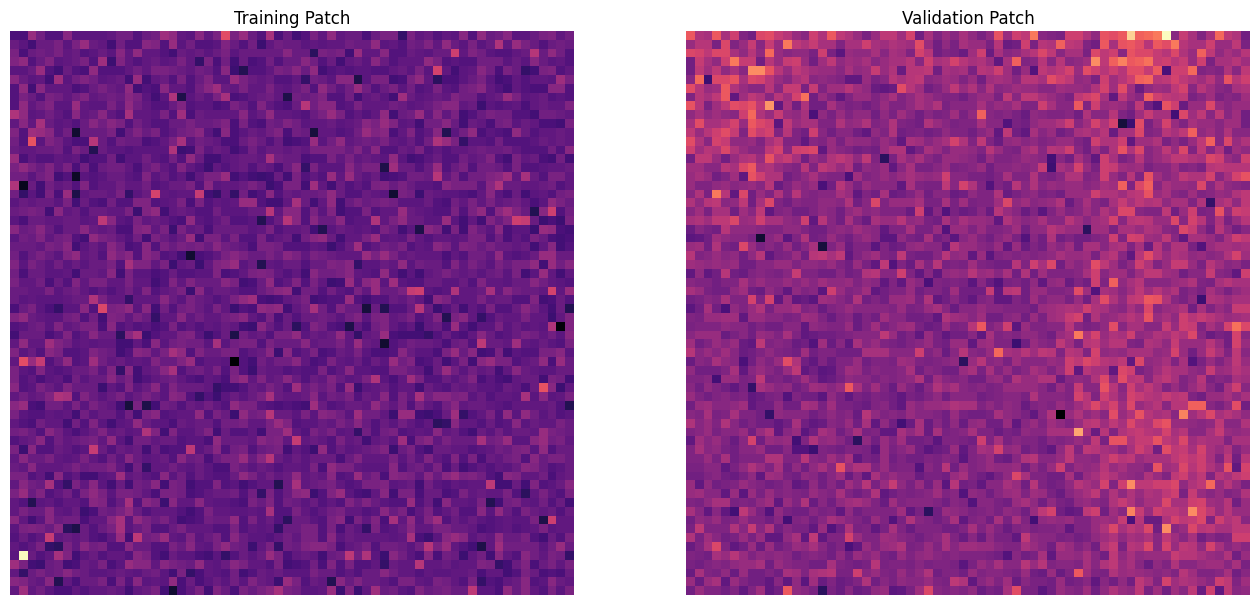

In [4]:
# Run this cell to execute the code
internal_aux_initial_time=datetime.now()
print('Runnning...')
print('--------------------------------------')

# --------------------- Here we delete the model folder if it already exist ------------------------

if os.path.exists(model_path+'/'+model_name):
  print(bcolors.WARNING +"!! WARNING: Model folder already exists and has been removed !!" + W)
  shutil.rmtree(model_path+'/'+model_name)

#Disable some of the warnings
import warnings
warnings.filterwarnings("ignore")

# Create batches from the training data.
patches = datagen.generate_patches_from_list(imgs, shape=(patch_height, patch_size, patch_size), augment=Use_Data_augmentation)

# Patches are divited into training and validation patch set. This inhibits over-lapping of patches. 
number_train_images =int(len(patches)*(percentage_validation/100))
X = patches[number_train_images:]
X_val = patches[:number_train_images]

print(len(patches),"patches created.")
print(number_train_images,"patch images for validation (",percentage_validation,"%).")
print((len(patches)-number_train_images),"patch images for training.")
%memit 

#Here we automatically define number_of_step in function of training data and batch size
if (Use_Default_Advanced_Parameters): 
  number_of_steps= int(X.shape[0]/batch_size) + 1

# --------------------- Using pretrained model ------------------------
#Here we ensure that the learning rate set correctly when using pre-trained models
if Use_pretrained_model:
  if Weights_choice == "last":
    initial_learning_rate = lastLearningRate

  if Weights_choice == "best":            
    initial_learning_rate = bestLearningRate
# --------------------- ---------------------- ------------------------

# creates Congfig object. 
config = N2VConfig(X, unet_kern_size=3, 
                   train_steps_per_epoch=number_of_steps,train_epochs=number_of_epochs, train_loss='mse', batch_norm=True, 
                   train_batch_size=batch_size, n2v_perc_pix=0.198, n2v_patch_shape=(patch_height, patch_size, patch_size), 
                   n2v_manipulator='uniform_withCP', n2v_neighborhood_radius=5, train_learning_rate = initial_learning_rate)

vars(config)

# Create the default model.
model = N2V(config=config, name=model_name, basedir=model_path)

# --------------------- Using pretrained model ------------------------
# Load the pretrained weights 
if Use_pretrained_model:
  model.load_weights(h5_file_path)
# --------------------- ---------------------- ------------------------

print("Parameters transferred into the model.")
print(config)

# Shows a training batch and a validation batch.
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.imshow(X[0,1,...,0],cmap='magma')
plt.axis('off')
plt.title('Training Patch');
plt.subplot(1,2,2)
plt.imshow(X_val[0,1,...,0],cmap='magma')
plt.axis('off')
plt.title('Validation Patch');

pdf_export(trained = False, pretrained_model = Use_pretrained_model)

print('--------------------------------------')
print(f'Finnished. Duration: {datetime.now() - internal_aux_initial_time}')

## **3.2. Start Training**
---
<font size = 4>When playing the cell below you should see updates after each epoch (round). Network training can take some time.

<font size = 4>* **CRITICAL NOTE:** Google Colab has a time limit for processing (to prevent using GPU power for datamining). Training time must be less than 12 hours! If training takes longer than 12 hours, please decrease the number of epochs or number of patches. Another way circumvent this is to save the parameters of the model after training and start training again from this point.

<font size = 4>**Of Note:** At the end of the training, your model will be automatically exported so it can be used in the CSBDeep Fiji plugin (N2V -- N2V Predict). You can find it in your model folder (export.bioimage.io.zip and model.yaml). In Fiji, Make sure to choose the right version of tensorflow. You can check at: Edit-- Options-- Tensorflow. Choose the version 1.4 (CPU or GPU depending on your system).

<font size = 4>Once training is complete, the trained model is automatically saved on your Google Drive, in the **model_path** folder that was selected in Section 3. It is however wise to download the folder as all data can be erased at the next training if using the same folder.


In [5]:
# Run this cell to execute the code
internal_aux_initial_time=datetime.now()
print('Runnning...')
print('--------------------------------------')
start = time.time()

%memit
# the training starts.
history = model.train(X, X_val)
%memit
print("Model training is now done.")

# convert the history.history dict to a pandas DataFrame:     
lossData = pd.DataFrame(history.history) 

if os.path.exists(model_path+"/"+model_name+"/Quality Control"):
  shutil.rmtree(model_path+"/"+model_name+"/Quality Control")

os.makedirs(model_path+"/"+model_name+"/Quality Control")

# The training evaluation.csv is saved (overwrites the Files if needed). 
lossDataCSVpath = model_path+'/'+model_name+'/Quality Control/training_evaluation.csv'
with open(lossDataCSVpath, 'w') as f:
  writer = csv.writer(f)
  writer.writerow(['loss','val_loss', 'learning rate'])
  for i in range(len(history.history['loss'])):
    writer.writerow([history.history['loss'][i], history.history['val_loss'][i], history.history['lr'][i]])

# Displaying the time elapsed for training
dt = time.time() - start
mins, sec = divmod(dt, 60) 
hour, mins = divmod(mins, 60) 
print("Time elapsed:",hour, "hour(s)",mins,"min(s)",round(sec),"sec(s)")

#model.export_TF(name='Noise2Void', 
                #description='Noise2Void 3D trained using ZeroCostDL4Mic.', 
                #authors=["You"],
               # test_img=X_val[0,...,0], axes='ZYX',
               # patch_shape=(patch_size, patch_size))

#print("Your model has been sucessfully exported and can now also be used in the CSBDeep Fiji plugin")

#Create a pdf document with training summary

pdf_export(trained=True, pretrained_model = Use_pretrained_model)

print('--------------------------------------')
print(f'Finnished. Duration: {datetime.now() - internal_aux_initial_time}')

Runnning...
--------------------------------------
peak memory: 5210.89 MiB, increment: 0.00 MiB
32 blind-spots will be generated per training patch of size (4, 64, 64).


Preparing validation data: 100%|██████████████████████████████████████████████████| 4915/4915 [00:00<00:00, 7967.71it/s]
2026-06-04 15:18:58.898825: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


Epoch 1/10


2026-06-04 15:19:01.160874: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2026-06-04 15:19:05.275886: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7120e7e16a60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-04 15:19:05.275917: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-06-04 15:19:05.408262: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-04 15:19:05.959644: I ./tensorflow/compiler/jit/device_compiler.h:180] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


346/346 [==============================] - ETA: 0s - loss: 0.3124 - n2v_mse: 0.3124 - n2v_abs: 0.4055

2026-06-04 15:20:25.028654: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


346/346 [==============================] - 90s 218ms/step - loss: 0.3124 - n2v_mse: 0.3124 - n2v_abs: 0.4055 - val_loss: 0.2295 - val_n2v_mse: 0.2298 - val_n2v_abs: 0.3674 - lr: 4.0000e-04
Epoch 2/10
346/346 [==============================] - 69s 201ms/step - loss: 0.2472 - n2v_mse: 0.2472 - n2v_abs: 0.3698 - val_loss: 0.1851 - val_n2v_mse: 0.1854 - val_n2v_abs: 0.3190 - lr: 4.0000e-04
Epoch 3/10
346/346 [==============================] - 70s 201ms/step - loss: 0.2472 - n2v_mse: 0.2472 - n2v_abs: 0.3688 - val_loss: 0.1847 - val_n2v_mse: 0.1850 - val_n2v_abs: 0.3059 - lr: 4.0000e-04
Epoch 4/10
346/346 [==============================] - 70s 202ms/step - loss: 0.2399 - n2v_mse: 0.2399 - n2v_abs: 0.3659 - val_loss: 0.1753 - val_n2v_mse: 0.1756 - val_n2v_abs: 0.2987 - lr: 4.0000e-04
Epoch 5/10
346/346 [==============================] - 70s 202ms/step - loss: 0.2408 - n2v_mse: 0.2408 - n2v_abs: 0.3646 - val_loss: 0.1723 - val_n2v_mse: 0.1726 - val_n2v_abs: 0.3014 - lr: 4.0000e-04
Epoch 6/10


Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>
Ignoring width="50%" specified on a <td> that is not in the first <tr>


--------------------------------------
Finnished. Duration: 0:12:12.679796


# **4. Evaluate your model**
---

<font size = 4>This section allows the user to perform important quality checks on the validity and generalisability of the trained model. 

<font size = 4>**We highly recommend to perform quality control on all newly trained models.**




In [ ]:
# Run this cell to visualize the parameters and click the button to execute the code
internal_aux_initial_time=datetime.now()
clear_output()

display(Markdown("### Do you want to assess the model you just trained ?"))
widget_Use_the_current_trained_model = widgets.Checkbox(value=True, style={'description_width': 'initial'}, description="Use_the_current_trained_model:")
display(widget_Use_the_current_trained_model)
display(Markdown("### If not, please provide the path to the model folder:"))
widget_QC_model_folder = widgets.Text(value="", style={'description_width': 'initial'}, description="QC_model_folder:")
display(widget_QC_model_folder)

def function_21(output_widget):
  output_widget.clear_output()
  with output_widget:
    global Use_the_current_trained_model
    global QC_model_folder

    global QC_model_name
    global QC_model_path
    global QC_model_name
    global QC_model_path
    global full_QC_model_path

    # model name and path
    Use_the_current_trained_model = widget_Use_the_current_trained_model.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_21_Use_the_current_trained_model', widget_Use_the_current_trained_model.value)
    
    QC_model_folder = widget_QC_model_folder.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_21_QC_model_folder', widget_QC_model_folder.value)
    
    #Here we define the loaded model name and path
    QC_model_name = os.path.basename(QC_model_folder)
    QC_model_path = os.path.dirname(QC_model_folder)
    
    if (Use_the_current_trained_model): 
      QC_model_name = model_name
      QC_model_path = model_path
    
    full_QC_model_path = QC_model_path+'/'+QC_model_name+'/'
    if os.path.exists(full_QC_model_path):
      print("The "+QC_model_name+" network will be evaluated")
    else:  
      print(bcolors.WARNING + '!! WARNING: The chosen model does not exist !!')
      print('Please make sure you provide a valid model path and model name before proceeding further.')
    
    plt.show()

def function_21_cache(output_widget):
    global Use_the_current_trained_model
    global QC_model_folder

    global QC_model_name
    global QC_model_path
    global QC_model_name
    global QC_model_path
    global full_QC_model_path

    cache_Use_the_current_trained_model = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_21_Use_the_current_trained_model')
    if cache_Use_the_current_trained_model != '':
        widget_Use_the_current_trained_model.value = cache_Use_the_current_trained_model
    
    cache_QC_model_folder = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_21_QC_model_folder')
    if cache_QC_model_folder != '':
        widget_QC_model_folder.value = cache_QC_model_folder
    
button_function_21 = widgets.Button(description='Load and run')
cache_button_function_21 = widgets.Button(description='Load prev. settings')
output_function_21 = widgets.Output()
display(widgets.HBox((button_function_21, cache_button_function_21)), output_function_21)
def aux_function_21(_):
  return function_21(output_function_21)

def aux_function_21_cache(_):
  return function_21_cache(output_function_21)

button_function_21.on_click(aux_function_21)
cache_button_function_21.on_click(aux_function_21_cache)
print('--------------------------------------------------------------')
print('^ Introduce the arguments and click "Load and run". ^')
print('^ Or first click "Load prev. settings" if any previous ^')
print('^ settings have been saved and then click "Load and run". ^')

## **4.1. Inspection of the loss function**
---

<font size = 4>First, it is good practice to evaluate the training progress by comparing the training loss with the validation loss. The latter is a metric which shows how well the network performs on a subset of unseen data which is set aside from the training dataset. For more information on this, see for example [this review](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6381354/) by Nichols *et al.*

<font size = 4>**Training loss** describes an error value after each epoch for the difference between the model's prediction and its ground-truth target.

<font size = 4>**Validation loss** describes the same error value between the model's prediction on a validation image and compared to it's target.

<font size = 4>During training both values should decrease before reaching a minimal value which does not decrease further even after more training. Comparing the development of the validation loss with the training loss can give insights into the model's performance.

<font size = 4>Decreasing **Training loss** and **Validation loss** indicates that training is still necessary and increasing the `number_of_epochs` is recommended. Note that the curves can look flat towards the right side, just because of the y-axis scaling. The network has reached convergence once the curves flatten out. After this point no further training is required. If the **Validation loss** suddenly increases again an the **Training loss** simultaneously goes towards zero, it means that the network is overfitting to the training data. In other words the network is remembering the exact patterns from the training data and no longer generalizes well to unseen data. In this case the training dataset has to be increased.


In [ ]:
# Run this cell to execute the code
internal_aux_initial_time=datetime.now()
print('Runnning...')
print('--------------------------------------')

lossDataFromCSV = []
vallossDataFromCSV = []

with open(QC_model_path+'/'+QC_model_name+'/Quality Control/training_evaluation.csv','r') as csvfile:
    csvRead = csv.reader(csvfile, delimiter=',')
    next(csvRead)
    for row in csvRead:
        lossDataFromCSV.append(float(row[0]))
        vallossDataFromCSV.append(float(row[1]))

epochNumber = range(len(lossDataFromCSV))
plt.figure(figsize=(15,10))

plt.subplot(2,1,1)
plt.plot(epochNumber,lossDataFromCSV, label='Training loss')
plt.plot(epochNumber,vallossDataFromCSV, label='Validation loss')
plt.title('Training loss and validation loss vs. epoch number (linear scale)')
plt.ylabel('Loss')
plt.xlabel('Epoch number')
plt.legend()

plt.subplot(2,1,2)
plt.semilogy(epochNumber,lossDataFromCSV, label='Training loss')
plt.semilogy(epochNumber,vallossDataFromCSV, label='Validation loss')
plt.title('Training loss and validation loss vs. epoch number (log scale)')
plt.ylabel('Loss')
plt.xlabel('Epoch number')
plt.legend()
plt.savefig(QC_model_path+'/'+QC_model_name+'/Quality Control/lossCurvePlots.png')
plt.show()

print('--------------------------------------')
print(f'Finnished. Duration: {datetime.now() - internal_aux_initial_time}')

## **4.2. Error mapping and quality metrics estimation**
---

<font size = 4>This section will display SSIM maps and RSE maps as well as calculating total SSIM, NRMSE and PSNR metrics for all the images provided in the "Source_QC_folder" and "Target_QC_folder" !

<font size = 4>**1. The SSIM (structural similarity) map** 

<font size = 4>The SSIM metric is used to evaluate whether two images contain the same structures. It is a normalized metric and an SSIM of 1 indicates a perfect similarity between two images. Therefore for SSIM, the closer to 1, the better. The SSIM maps are constructed by calculating the SSIM metric in each pixel by considering the surrounding structural similarity in the neighbourhood of that pixel (currently defined as window of 11 pixels and with Gaussian weighting of 1.5 pixel standard deviation, see our Wiki for more info). 

<font size=4>**mSSIM** is the SSIM value calculated across the entire window of both images.

<font size=4>**The output below shows the SSIM maps with the mSSIM**

<font size = 4>**2. The RSE (Root Squared Error) map** 

<font size = 4>This is a display of the root of the squared difference between the normalized predicted and target or the source and the target. In this case, a smaller RSE is better. A perfect agreement between target and prediction will lead to an RSE map showing zeros everywhere (dark).


<font size =4>**NRMSE (normalised root mean squared error)** gives the average difference between all pixels in the images compared to each other. Good agreement yields low NRMSE scores.

<font size = 4>**PSNR (Peak signal-to-noise ratio)** is a metric that gives the difference between the ground truth and prediction (or source input) in decibels, using the peak pixel values of the prediction and the MSE between the images. The higher the score the better the agreement.

<font size=4>**The output below shows the RSE maps with the NRMSE and PSNR values.**



In [ ]:
# Run this cell to visualize the parameters and click the button to execute the code
internal_aux_initial_time=datetime.now()
clear_output()

display(Markdown("## Choose the folders that contain your Quality Control dataset"))
widget_Source_QC_folder = widgets.Text(value="", style={'description_width': 'initial'}, description="Source_QC_folder:")
display(widget_Source_QC_folder)
widget_Target_QC_folder = widgets.Text(value="", style={'description_width': 'initial'}, description="Target_QC_folder:")
display(widget_Target_QC_folder)
display(Markdown("##### To analyse large image, your images need to be divided into tiles.  Each tile will then be processed independently and re-assembled to generate the final image. 'Automatic_number_of_tiles' will search for and use the smallest number of tiles that can be used, at the expanse of your runtime. Alternatively, manually input the number of tiles in each dimension to be used to process your images. "))
widget_Automatic_number_of_tiles = widgets.Checkbox(value=False, style={'description_width': 'initial'}, description="Automatic_number_of_tiles:")
display(widget_Automatic_number_of_tiles)
display(Markdown("##### If you get an Out of memory (OOM) error when using the 'Automatic_number_of_tiles' option, disable it and manually input the values to be used to process your images.  Progressively increases these numbers until the OOM error disappear."))
widget_n_tiles_Z = widgets.IntText(value=1, style={'description_width': 'initial'}, description="n_tiles_Z:")
display(widget_n_tiles_Z)
widget_n_tiles_Y = widgets.IntText(value=2, style={'description_width': 'initial'}, description="n_tiles_Y:")
display(widget_n_tiles_Y)
widget_n_tiles_X = widgets.IntText(value=2, style={'description_width': 'initial'}, description="n_tiles_X:")
display(widget_n_tiles_X)

def function_25(output_widget):
  output_widget.clear_output()
  with output_widget:
    global Source_QC_folder
    global Target_QC_folder
    global Automatic_number_of_tiles
    global n_tiles_Z
    global n_tiles_Y
    global n_tiles_X

    global path_metrics_save
    global n_tilesZYX
    global n_tilesZYX
    global model_training
    global Source_QC_folder_tif
    global Z
    global Z
    global img
    global n_slices
    global predicted
    global mi
    global ma
    global x
    global mi
    global ma
    global eps
    global x
    global x
    global x
    global gt
    global x
    global gt
    global scale
    global writer
    global file_name_list
    global slice_number_list
    global mSSIM_GvP_list
    global mSSIM_GvS_list
    global NRMSE_GvP_list
    global NRMSE_GvS_list
    global PSNR_GvP_list
    global PSNR_GvS_list
    global mSSIM_GvP_list_mean
    global mSSIM_GvS_list_mean
    global NRMSE_GvP_list_mean
    global NRMSE_GvS_list_mean
    global PSNR_GvP_list_mean
    global PSNR_GvS_list_mean
    global test_GT_stack
    global test_source_stack
    global test_prediction_stack
    global n_slices
    global z_mid_plane
    global img_SSIM_GTvsPrediction_stack
    global img_SSIM_GTvsSource_stack
    global img_RSE_GTvsPrediction_stack
    global img_RSE_GTvsSource_stack
    global test_GT_norm
    global test_source_norm
    global test_GT_norm
    global test_prediction_norm
    global index_SSIM_GTvsPrediction
    global  img_SSIM_GTvsPrediction
    global index_SSIM_GTvsSource
    global  img_SSIM_GTvsSource
    global img_RSE_GTvsPrediction
    global img_RSE_GTvsSource
    global NRMSE_GTvsPrediction
    global NRMSE_GTvsSource
    global PSNR_GTvsPrediction
    global PSNR_GTvsSource
    global SSIM_GTvsP_forDisplay
    global SSIM_GTvsS_forDisplay
    global NRMSE_GTvsP_forDisplay
    global NRMSE_GTvsS_forDisplay
    global img_SSIM_GTvsSource_stack_32
    global img_SSIM_GTvsPrediction_stack_32
    global img_RSE_GTvsSource_stack_32
    global img_RSE_GTvsPrediction_stack_32
    global pdResults
    global Test_FileList
    global img_GT
    global z_mid_plane
    global img_Source
    global img_Prediction
    global cmap
    global axis
    global which
    global bottom
    global top
    global left
    global right
    global labelbottom
    global labelleft
    global img_SSIM_GTvsSource
    global imSSIM_GTvsSource
    global axis
    global which
    global bottom
    global top
    global left
    global right
    global labelbottom
    global labelleft
    global img_SSIM_GTvsPrediction
    global imSSIM_GTvsPrediction
    global axis
    global which
    global bottom
    global top
    global left
    global right
    global labelbottom
    global labelleft
    global img_RSE_GTvsSource
    global imRSE_GTvsSource
    global axis
    global which
    global bottom
    global top
    global left
    global right
    global labelbottom
    global labelleft
    global img_RSE_GTvsPrediction
    global imRSE_GTvsPrediction

    global normalize
    global norm_minmse

    Source_QC_folder = widget_Source_QC_folder.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_25_Source_QC_folder', widget_Source_QC_folder.value)
    Target_QC_folder = widget_Target_QC_folder.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_25_Target_QC_folder', widget_Target_QC_folder.value)
    
    path_metrics_save = os.path.join(QC_model_path, QC_model_name, 'Quality Control')
    
    # Create a quality control/Prediction Folder
    if os.path.exists(os.path.join(path_metrics_save, 'Prediction')):
      shutil.rmtree(os.path.join(path_metrics_save, 'Prediction'))
    os.makedirs(os.path.join(path_metrics_save, 'Prediction'))
    
    #Here we allow the user to choose the number of tile to be used when predicting the images
    
    Automatic_number_of_tiles = widget_Automatic_number_of_tiles.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_25_Automatic_number_of_tiles', widget_Automatic_number_of_tiles.value)
    n_tiles_Z = widget_n_tiles_Z.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_25_n_tiles_Z', widget_n_tiles_Z.value)
    n_tiles_Y = widget_n_tiles_Y.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_25_n_tiles_Y', widget_n_tiles_Y.value)
    n_tiles_X = widget_n_tiles_X.value
    ipywidgets_edit_yaml(ipywidgets_edit_yaml_config_path, 'function_25_n_tiles_X', widget_n_tiles_X.value)
    
    if (Automatic_number_of_tiles): 
      n_tilesZYX = None
    
    if not (Automatic_number_of_tiles):
      n_tilesZYX = (n_tiles_Z, n_tiles_Y, n_tiles_X)
    
    # Activate the pretrained model. 
    model_training = N2V(config=None, name=QC_model_name, basedir=QC_model_path)
    
    # List Tif images in Source_QC_folder
    Source_QC_folder_tif = Source_QC_folder+"/*.tif"
    Z = sorted(glob(Source_QC_folder_tif))
    Z = list(map(imread,Z))
    print('Number of test dataset found in the folder: '+str(len(Z)))
    
    # Perform prediction on all datasets in the Source_QC folder
    for filename in os.listdir(Source_QC_folder):
      img = imread(os.path.join(Source_QC_folder, filename))
      n_slices = img.shape[0]
      predicted = model_training.predict(img, axes='ZYX', n_tiles=n_tilesZYX)
      imsave(os.path.join(path_metrics_save, 'Prediction', 'Predicted_'+filename), predicted)
    
    def normalize(x, pmin=3, pmax=99.8, axis=None, clip=False, eps=1e-20, dtype=np.float32):
        """This function is adapted from Martin Weigert"""
        """Percentile-based image normalization."""
    
        mi = np.percentile(x,pmin,axis=axis,keepdims=True)
        ma = np.percentile(x,pmax,axis=axis,keepdims=True)
        return normalize_mi_ma(x, mi, ma, clip=clip, eps=eps, dtype=dtype)
    
    def normalize_mi_ma(x, mi, ma, clip=False, eps=1e-20, dtype=np.float32):#dtype=np.float32
        """This function is adapted from Martin Weigert"""
        if dtype is not None:
            x   = x.astype(dtype,copy=False)
            mi  = dtype(mi) if np.isscalar(mi) else mi.astype(dtype,copy=False)
            ma  = dtype(ma) if np.isscalar(ma) else ma.astype(dtype,copy=False)
            eps = dtype(eps)
    
        try:
            import numexpr
            x = numexpr.evaluate("(x - mi) / ( ma - mi + eps )")
        except ImportError:
            x =                   (x - mi) / ( ma - mi + eps )
    
        if clip:
            x = np.clip(x,0,1)
    
        return x
    
    def norm_minmse(gt, x, normalize_gt=True):
        """This function is adapted from Martin Weigert"""
    
        """
        normalizes and affinely scales an image pair such that the MSE is minimized  
         
        Parameters
        ----------
        gt: ndarray
            the ground truth image      
        x: ndarray
            the image that will be affinely scaled 
        normalize_gt: bool
            set to True of gt image should be normalized (default)
        Returns
        -------
        gt_scaled, x_scaled 
        """
        if normalize_gt:
            gt = normalize(gt, 0.1, 99.9, clip=False).astype(np.float32, copy = False)
        x = x.astype(np.float32, copy=False) - np.mean(x)
        #x = x - np.mean(x)
        gt = gt.astype(np.float32, copy=False) - np.mean(gt)
        #gt = gt - np.mean(gt)
        scale = np.cov(x.flatten(), gt.flatten())[0, 1] / np.var(x.flatten())
        return gt, scale * x
    
    # Open and create the csv file that will contain all the QC metrics
    with open(path_metrics_save+'QC_metrics_'+QC_model_name+".csv", "w", newline='') as file:
        writer = csv.writer(file)
    
        # Write the header in the csv file
        writer.writerow(["File name","Slice #","Prediction v. GT mSSIM","Input v. GT mSSIM", "Prediction v. GT NRMSE", "Input v. GT NRMSE", "Prediction v. GT PSNR", "Input v. GT PSNR"])  
        
        # These lists will be used to collect all the metrics values per slice
        file_name_list = []
        slice_number_list = []
        mSSIM_GvP_list = []
        mSSIM_GvS_list = []
        NRMSE_GvP_list = []
        NRMSE_GvS_list = []
        PSNR_GvP_list = []
        PSNR_GvS_list = []
    
        # These lists will be used to display the mean metrics for the stacks
        mSSIM_GvP_list_mean = []
        mSSIM_GvS_list_mean = []
        NRMSE_GvP_list_mean = []
        NRMSE_GvS_list_mean = []
        PSNR_GvP_list_mean = []
        PSNR_GvS_list_mean = []
    
        # Let's loop through the provided dataset in the QC folders
        for thisFile in os.listdir(Source_QC_folder):
          if not os.path.isdir(os.path.join(Source_QC_folder, thisFile)):
            print('Running QC on: '+thisFile)
    
            test_GT_stack = io.imread(os.path.join(Target_QC_folder, thisFile))
            test_source_stack = io.imread(os.path.join(Source_QC_folder,thisFile))
            test_prediction_stack = io.imread(os.path.join(path_metrics_save+"Prediction/",'Predicted_'+thisFile))
            n_slices = test_GT_stack.shape[0]
    
            # Calculating the position of the mid-plane slice
            z_mid_plane = int(n_slices / 2)+1
    
            img_SSIM_GTvsPrediction_stack = np.zeros((n_slices, test_GT_stack.shape[1], test_GT_stack.shape[2]))
            img_SSIM_GTvsSource_stack = np.zeros((n_slices, test_GT_stack.shape[1], test_GT_stack.shape[2]))
            img_RSE_GTvsPrediction_stack = np.zeros((n_slices, test_GT_stack.shape[1], test_GT_stack.shape[2]))
            img_RSE_GTvsSource_stack = np.zeros((n_slices, test_GT_stack.shape[1], test_GT_stack.shape[2]))
    
            for z in range(n_slices): 
              # -------------------------------- Normalising the dataset --------------------------------
    
              test_GT_norm,test_source_norm = norm_minmse(test_GT_stack[z], test_source_stack[z], normalize_gt=True)
              test_GT_norm,test_prediction_norm = norm_minmse(test_GT_stack[z], test_prediction_stack[z], normalize_gt=True)
    
              # -------------------------------- Calculate the SSIM metric and maps --------------------------------
              # Calculate the SSIM maps and index
              index_SSIM_GTvsPrediction, img_SSIM_GTvsPrediction = structural_similarity(test_GT_norm, test_prediction_norm, data_range=1.0, full=True, gaussian_weights=True, use_sample_covariance=False, sigma=1.5)
              index_SSIM_GTvsSource, img_SSIM_GTvsSource = structural_similarity(test_GT_norm, test_source_norm, data_range=1.0, full=True, gaussian_weights=True, use_sample_covariance=False, sigma=1.5)
    
              #Calculate ssim_maps
              img_SSIM_GTvsPrediction_stack[z] = img_as_float32(img_SSIM_GTvsPrediction,force_copy=False)
              img_SSIM_GTvsSource_stack[z] = img_as_float32(img_SSIM_GTvsSource,force_copy=False)
          
              # -------------------------------- Calculate the NRMSE metrics --------------------------------
    
              # Calculate the Root Squared Error (RSE) maps
              img_RSE_GTvsPrediction = np.sqrt(np.square(test_GT_norm - test_prediction_norm))
              img_RSE_GTvsSource = np.sqrt(np.square(test_GT_norm - test_source_norm))
    
              # Calculate SE maps
              img_RSE_GTvsPrediction_stack[z] = img_as_float32(img_RSE_GTvsPrediction)
              img_RSE_GTvsSource_stack[z] = img_as_float32(img_RSE_GTvsSource)
    
              # Normalised Root Mean Squared Error (here it's valid to take the mean of the image)
              NRMSE_GTvsPrediction = np.sqrt(np.mean(img_RSE_GTvsPrediction))
              NRMSE_GTvsSource = np.sqrt(np.mean(img_RSE_GTvsSource))
    
              # Calculate the PSNR between the images
              PSNR_GTvsPrediction = psnr(test_GT_norm,test_prediction_norm,data_range=1.0)
              PSNR_GTvsSource = psnr(test_GT_norm,test_source_norm,data_range=1.0)
    
              writer.writerow([thisFile, str(z),str(index_SSIM_GTvsPrediction),str(index_SSIM_GTvsSource),str(NRMSE_GTvsPrediction),str(NRMSE_GTvsSource), str(PSNR_GTvsPrediction), str(PSNR_GTvsSource)])
              
              # Collect values to display in dataframe output
              slice_number_list.append(z)
              mSSIM_GvP_list.append(index_SSIM_GTvsPrediction)
              mSSIM_GvS_list.append(index_SSIM_GTvsSource)
              NRMSE_GvP_list.append(NRMSE_GTvsPrediction)
              NRMSE_GvS_list.append(NRMSE_GTvsSource)
              PSNR_GvP_list.append(PSNR_GTvsPrediction)
              PSNR_GvS_list.append(PSNR_GTvsSource)
    
              if (z == z_mid_plane): # catch these for display
                SSIM_GTvsP_forDisplay = index_SSIM_GTvsPrediction
                SSIM_GTvsS_forDisplay = index_SSIM_GTvsSource
                NRMSE_GTvsP_forDisplay = NRMSE_GTvsPrediction
                NRMSE_GTvsS_forDisplay = NRMSE_GTvsSource
            
            # If calculating average metrics for dataframe output
            file_name_list.append(thisFile)
            mSSIM_GvP_list_mean.append(sum(mSSIM_GvP_list)/len(mSSIM_GvP_list))
            mSSIM_GvS_list_mean.append(sum(mSSIM_GvS_list)/len(mSSIM_GvS_list))
            NRMSE_GvP_list_mean.append(sum(NRMSE_GvP_list)/len(NRMSE_GvP_list))
            NRMSE_GvS_list_mean.append(sum(NRMSE_GvS_list)/len(NRMSE_GvS_list))
            PSNR_GvP_list_mean.append(sum(PSNR_GvP_list)/len(PSNR_GvP_list))
            PSNR_GvS_list_mean.append(sum(PSNR_GvS_list)/len(PSNR_GvS_list))
    
            # ----------- Change the stacks to 32 bit images -----------
    
            img_SSIM_GTvsSource_stack_32 = img_as_float32(img_SSIM_GTvsSource_stack, force_copy=False)
            img_SSIM_GTvsPrediction_stack_32 = img_as_float32(img_SSIM_GTvsPrediction_stack, force_copy=False)
            img_RSE_GTvsSource_stack_32 = img_as_float32(img_RSE_GTvsSource_stack, force_copy=False)
            img_RSE_GTvsPrediction_stack_32 = img_as_float32(img_RSE_GTvsPrediction_stack, force_copy=False)
    
            # ----------- Saving the error map stacks -----------
            io.imsave(path_metrics_save+'SSIM_GTvsSource_'+thisFile,img_SSIM_GTvsSource_stack_32)
            io.imsave(path_metrics_save+'SSIM_GTvsPrediction_'+thisFile,img_SSIM_GTvsPrediction_stack_32)
            io.imsave(path_metrics_save+'RSE_GTvsSource_'+thisFile,img_RSE_GTvsSource_stack_32)
            io.imsave(path_metrics_save+'RSE_GTvsPrediction_'+thisFile,img_RSE_GTvsPrediction_stack_32)
    
    #Averages of the metrics per stack as dataframe output
    pdResults = pd.DataFrame(file_name_list, columns = ["File name"])
    pdResults["Prediction v. GT mSSIM"] = mSSIM_GvP_list_mean
    pdResults["Input v. GT mSSIM"] = mSSIM_GvS_list_mean
    pdResults["Prediction v. GT NRMSE"] = NRMSE_GvP_list_mean
    pdResults["Input v. GT NRMSE"] = NRMSE_GvS_list_mean
    pdResults["Prediction v. GT PSNR"] = PSNR_GvP_list_mean
    pdResults["Input v. GT PSNR"] = PSNR_GvS_list_mean
    
    # All data is now processed saved
    Test_FileList = os.listdir(Source_QC_folder) # this assumes, as it should, that both source and target are named the same way
    
    plt.figure(figsize=(15,15))
    # Currently only displays the last computed set, from memory
    # Target (Ground-truth)
    plt.subplot(3,3,1)
    plt.axis('off')
    img_GT = io.imread(os.path.join(Target_QC_folder, Test_FileList[-1]))
    
    # Calculating the position of the mid-plane slice
    z_mid_plane = int(img_GT.shape[0] / 2)+1
    
    plt.imshow(img_GT[z_mid_plane])
    plt.title('Target (slice #'+str(z_mid_plane)+')')
    
    # Source
    plt.subplot(3,3,2)
    plt.axis('off')
    img_Source = io.imread(os.path.join(Source_QC_folder, Test_FileList[-1]))
    plt.imshow(img_Source[z_mid_plane])
    plt.title('Source (slice #'+str(z_mid_plane)+')')
    
    #Prediction
    plt.subplot(3,3,3)
    plt.axis('off')
    img_Prediction = io.imread(os.path.join(path_metrics_save+'Prediction/', 'Predicted_'+Test_FileList[-1]))
    plt.imshow(img_Prediction[z_mid_plane])
    plt.title('Prediction (slice #'+str(z_mid_plane)+')')
    
    #Setting up colours
    cmap = plt.cm.CMRmap
    
    #SSIM between GT and Source
    plt.subplot(3,3,5)
    #plt.axis('off')
    plt.tick_params(
        axis='both',      # changes apply to the x-axis and y-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,        # ticks along the top edge are off
        left=False,       # ticks along the left edge are off
        right=False,         # ticks along the right edge are off
        labelbottom=False,
        labelleft=False)
    img_SSIM_GTvsSource = io.imread(os.path.join(path_metrics_save, 'SSIM_GTvsSource_'+Test_FileList[-1]))
    imSSIM_GTvsSource = plt.imshow(img_SSIM_GTvsSource[z_mid_plane], cmap = cmap, vmin=0, vmax=1)
    plt.colorbar(imSSIM_GTvsSource,fraction=0.046, pad=0.04)
    plt.title('Target vs. Source',fontsize=15)
    plt.xlabel('mSSIM: '+str(round(SSIM_GTvsS_forDisplay,3)),fontsize=14)
    plt.ylabel('SSIM maps',fontsize=20, rotation=0, labelpad=75)
    
    #SSIM between GT and Prediction
    plt.subplot(3,3,6)
    #plt.axis('off')
    plt.tick_params(
        axis='both',      # changes apply to the x-axis and y-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,        # ticks along the top edge are off
        left=False,       # ticks along the left edge are off
        right=False,         # ticks along the right edge are off
        labelbottom=False,
        labelleft=False)  
    img_SSIM_GTvsPrediction = io.imread(os.path.join(path_metrics_save, 'SSIM_GTvsPrediction_'+Test_FileList[-1]))
    imSSIM_GTvsPrediction = plt.imshow(img_SSIM_GTvsPrediction[z_mid_plane], cmap = cmap, vmin=0,vmax=1)
    plt.colorbar(imSSIM_GTvsPrediction,fraction=0.046, pad=0.04)
    plt.title('Target vs. Prediction',fontsize=15)
    plt.xlabel('mSSIM: '+str(round(SSIM_GTvsP_forDisplay,3)),fontsize=14)
    
    #Root Squared Error between GT and Source
    plt.subplot(3,3,8)
    #plt.axis('off')
    plt.tick_params(
        axis='both',      # changes apply to the x-axis and y-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,        # ticks along the top edge are off
        left=False,       # ticks along the left edge are off
        right=False,         # ticks along the right edge are off
        labelbottom=False,
        labelleft=False)
    img_RSE_GTvsSource = io.imread(os.path.join(path_metrics_save, 'RSE_GTvsSource_'+Test_FileList[-1]))
    imRSE_GTvsSource = plt.imshow(img_RSE_GTvsSource[z_mid_plane], cmap = cmap, vmin=0, vmax = 1) 
    plt.colorbar(imRSE_GTvsSource,fraction=0.046,pad=0.04)
    plt.title('Target vs. Source',fontsize=15)
    plt.xlabel('NRMSE: '+str(round(NRMSE_GTvsS_forDisplay,3))+', PSNR: '+str(round(PSNR_GTvsSource,3)),fontsize=14)
    #plt.title('Target vs. Source PSNR: '+str(round(PSNR_GTvsSource,3)))
    plt.ylabel('RSE maps',fontsize=20, rotation=0, labelpad=75)
    
    #Root Squared Error between GT and Prediction
    plt.subplot(3,3,9)
    #plt.axis('off')
    plt.tick_params(
        axis='both',      # changes apply to the x-axis and y-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,        # ticks along the top edge are off
        left=False,       # ticks along the left edge are off
        right=False,         # ticks along the right edge are off
        labelbottom=False,
        labelleft=False) 
    img_RSE_GTvsPrediction = io.imread(os.path.join(path_metrics_save, 'RSE_GTvsPrediction_'+Test_FileList[-1]))
    imRSE_GTvsPrediction = plt.imshow(img_RSE_GTvsPrediction[z_mid_plane], cmap = cmap, vmin=0, vmax=1)
    plt.colorbar(imRSE_GTvsPrediction,fraction=0.046,pad=0.04)
    plt.title('Target vs. Prediction',fontsize=15)
    plt.xlabel('NRMSE: '+str(round(NRMSE_GTvsP_forDisplay,3))+', PSNR: '+str(round(PSNR_GTvsPrediction,3)),fontsize=14)
    plt.savefig(full_QC_model_path+'/Quality Control/QC_example_data.png',bbox_inches='tight',pad_inches=0)
    print('-----------------------------------')
    print('Here are the average scores for the stacks you tested in Quality control. To see values for all slices, open the .csv file saved in the Qulity Control folder.')
    pdResults.head()
    
    #Make a pdf summary of the QC results
    
    qc_pdf_export()
    
    plt.show()

def function_25_cache(output_widget):
    global Source_QC_folder
    global Target_QC_folder
    global Automatic_number_of_tiles
    global n_tiles_Z
    global n_tiles_Y
    global n_tiles_X

    global path_metrics_save
    global n_tilesZYX
    global n_tilesZYX
    global model_training
    global Source_QC_folder_tif
    global Z
    global Z
    global img
    global n_slices
    global predicted
    global mi
    global ma
    global x
    global mi
    global ma
    global eps
    global x
    global x
    global x
    global gt
    global x
    global gt
    global scale
    global writer
    global file_name_list
    global slice_number_list
    global mSSIM_GvP_list
    global mSSIM_GvS_list
    global NRMSE_GvP_list
    global NRMSE_GvS_list
    global PSNR_GvP_list
    global PSNR_GvS_list
    global mSSIM_GvP_list_mean
    global mSSIM_GvS_list_mean
    global NRMSE_GvP_list_mean
    global NRMSE_GvS_list_mean
    global PSNR_GvP_list_mean
    global PSNR_GvS_list_mean
    global test_GT_stack
    global test_source_stack
    global test_prediction_stack
    global n_slices
    global z_mid_plane
    global img_SSIM_GTvsPrediction_stack
    global img_SSIM_GTvsSource_stack
    global img_RSE_GTvsPrediction_stack
    global img_RSE_GTvsSource_stack
    global test_GT_norm
    global test_source_norm
    global test_GT_norm
    global test_prediction_norm
    global index_SSIM_GTvsPrediction
    global  img_SSIM_GTvsPrediction
    global index_SSIM_GTvsSource
    global  img_SSIM_GTvsSource
    global img_RSE_GTvsPrediction
    global img_RSE_GTvsSource
    global NRMSE_GTvsPrediction
    global NRMSE_GTvsSource
    global PSNR_GTvsPrediction
    global PSNR_GTvsSource
    global SSIM_GTvsP_forDisplay
    global SSIM_GTvsS_forDisplay
    global NRMSE_GTvsP_forDisplay
    global NRMSE_GTvsS_forDisplay
    global img_SSIM_GTvsSource_stack_32
    global img_SSIM_GTvsPrediction_stack_32
    global img_RSE_GTvsSource_stack_32
    global img_RSE_GTvsPrediction_stack_32
    global pdResults
    global Test_FileList
    global img_GT
    global z_mid_plane
    global img_Source
    global img_Prediction
    global cmap
    global axis
    global which
    global bottom
    global top
    global left
    global right
    global labelbottom
    global labelleft
    global img_SSIM_GTvsSource
    global imSSIM_GTvsSource
    global axis
    global which
    global bottom
    global top
    global left
    global right
    global labelbottom
    global labelleft
    global img_SSIM_GTvsPrediction
    global imSSIM_GTvsPrediction
    global axis
    global which
    global bottom
    global top
    global left
    global right
    global labelbottom
    global labelleft
    global img_RSE_GTvsSource
    global imRSE_GTvsSource
    global axis
    global which
    global bottom
    global top
    global left
    global right
    global labelbottom
    global labelleft
    global img_RSE_GTvsPrediction
    global imRSE_GTvsPrediction

    global normalize
    global norm_minmse

    cache_Source_QC_folder = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_25_Source_QC_folder')
    if cache_Source_QC_folder != '':
        widget_Source_QC_folder.value = cache_Source_QC_folder
    
    cache_Target_QC_folder = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_25_Target_QC_folder')
    if cache_Target_QC_folder != '':
        widget_Target_QC_folder.value = cache_Target_QC_folder
    
    cache_Automatic_number_of_tiles = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_25_Automatic_number_of_tiles')
    if cache_Automatic_number_of_tiles != '':
        widget_Automatic_number_of_tiles.value = cache_Automatic_number_of_tiles
    
    cache_n_tiles_Z = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_25_n_tiles_Z')
    if cache_n_tiles_Z != '':
        widget_n_tiles_Z.value = cache_n_tiles_Z
    
    cache_n_tiles_Y = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_25_n_tiles_Y')
    if cache_n_tiles_Y != '':
        widget_n_tiles_Y.value = cache_n_tiles_Y
    
    cache_n_tiles_X = ipywidgets_read_yaml(ipywidgets_edit_yaml_config_path, 'function_25_n_tiles_X')
    if cache_n_tiles_X != '':
        widget_n_tiles_X.value = cache_n_tiles_X
    
button_function_25 = widgets.Button(description='Load and run')
cache_button_function_25 = widgets.Button(description='Load prev. settings')
output_function_25 = widgets.Output()
display(widgets.HBox((button_function_25, cache_button_function_25)), output_function_25)
def aux_function_25(_):
  return function_25(output_function_25)

def aux_function_25_cache(_):
  return function_25_cache(output_function_25)

button_function_25.on_click(aux_function_25)
cache_button_function_25.on_click(aux_function_25_cache)
print('--------------------------------------------------------------')
print('^ Introduce the arguments and click "Load and run". ^')
print('^ Or first click "Load prev. settings" if any previous ^')
print('^ settings have been saved and then click "Load and run". ^')

# **5. Using the trained model**

---

<font size = 4>In this section the unseen data is processed using the trained model (in section 4). First, your unseen images are uploaded and prepared for prediction. After that your trained model from section 4 is activated and finally saved into your Google Drive.


## **5.1. Generate prediction(s) from unseen dataset**
---

<font size = 4>The current trained model (from section 4.2) can now be used to process images. If you want to use an older model, untick the **Use_the_current_trained_model** box and enter the name and path of the model to use. Predicted output images are saved in your **Result_folder** folder as restored image stacks (ImageJ-compatible TIFF images).

<font size = 4>**`Data_folder`:** This folder should contain the images that you want to use your trained network on for processing.

<font size = 4>**`Result_folder`:** This folder will contain the predicted output images.


## **5.2. Save Model to BioImage Model Zoo Format**
---

<font size = 4>This is an optional step to allow you to export your trained model to be uploaded to the bioimage model zoo, and/or used in DeepImageJ locally. 

<font size = 4>Running the below code block should export your model to the model folder as **your model name.zip**.


In [15]:
import os

# Path where the documentation file will be saved
doc_path = "/tmp/bmz_export/documentation.md"

doc_content = """# My N2V 3D Denoising Model## Overview
This model was trained using Noise2Void (N2V) 3D, a self-supervised deep learning 
method for denoising 3D microscopy images. No clean images are required for training — 
only the noisy images themselves.

## Training Data
- Describe your sample type here (e.g. "3D fluorescence microscopy images of...")
- Image dimensions: Z x Y x X
- Number of training images used:
- Voxel size:

## Training Settings
- Patch size: 
- Number of epochs:
- Batch size:
- Learning rate:

## Intended Use
Denoising of 3D fluorescence microscopy images with similar characteristics 
to the training data.

## Limitations
This model is trained on a specific dataset and may not generalise well to 
images with different noise characteristics or sample types.

## Citations
- Krull et al. Noise2Void. CVPR 2019. https://doi.org/10.1109/CVPR.2019.00223
- von Chamier et al. ZeroCostDL4Mic. Nat Commun 2021. https://doi.org/10.1038/s41467-021-22518-0
- Hidalgo-Cenalmor et al. DL4MicEverywhere. Nat Methods 2024. https://doi.org/10.1038/s41592-024-02295-6
"""

with open(doc_path, 'w') as f:
    f.write(doc_content)

print(f"Documentation file written to: {doc_path}")
!cat {doc_path}

Documentation file written to: /tmp/bmz_export/documentation.md
# My N2V 3D Denoising Model## Overview
This model was trained using Noise2Void (N2V) 3D, a self-supervised deep learning 
method for denoising 3D microscopy images. No clean images are required for training — 
only the noisy images themselves.

## Training Data
- Describe your sample type here (e.g. "3D fluorescence microscopy images of...")
- Image dimensions: Z x Y x X
- Number of training images used:
- Voxel size:

## Training Settings
- Patch size: 
- Number of epochs:
- Batch size:
- Learning rate:

## Intended Use
Denoising of 3D fluorescence microscopy images with similar characteristics 
to the training data.

## Limitations
This model is trained on a specific dataset and may not generalise well to 
images with different noise characteristics or sample types.

## Citations
- Krull et al. Noise2Void. CVPR 2019. https://doi.org/10.1109/CVPR.2019.00223
- von Chamier et al. ZeroCostDL4Mic. Nat Commun 2021. https://doi

In [16]:
import numpy as np
import tifffile
from bioimageio.core.build_spec import build_model
from pathlib import Path
import os

# --- EDIT THESE ---
random_choice=random.choice(os.listdir(Training_source))
    
test_image_path = Training_source+"/"+random_choice
model_save_dir  = model_path+model_name
print(model_save_dir)
output_zip      = model_path+model_name+"/"+model_name+".zip"
# ------------------

# Load test image and generate example output
test_input = tifffile.imread(test_image_path).astype(np.float32)
test_output = model.predict(test_input, axes="ZYX")

# Add batch and channel dimensions → BCZYX
test_input_bc  = test_input[np.newaxis, np.newaxis]
test_output_bc = test_output[np.newaxis, np.newaxis]

# Save as npy files (build_model needs file paths, not arrays)
os.makedirs("/tmp/bmz_export", exist_ok=True)
np.save("/tmp/bmz_export/test_input.npy",  test_input_bc)
np.save("/tmp/bmz_export/test_output.npy", test_output_bc)

# Find the weights file
weights_path = Path(model_save_dir) / "weights_best.h5"
if not weights_path.exists():
    # sometimes named differently
    candidates = list(Path(model_save_dir).glob("*.h5"))
    print("Available weight files:", candidates)
    weights_path = candidates[0]  # pick the first one found

print(f"Using weights: {weights_path}")

build_model(
    weight_uri        = weights_path,
    weight_type       = "keras_hdf5",
    test_inputs       = ["/tmp/bmz_export/test_input.npy"],
    test_outputs      = ["/tmp/bmz_export/test_output.npy"],
    input_axes        = ["bczyx"],
    output_axes       = ["bczyx"],
    output_path       = output_zip,
    name              = "MyN2V3D_model",
    description       = "3D Noise2Void denoising model trained with DL4MicEverywhere",
    authors           = [{"name": "Your Name", "affiliation": "Your Institution"}],
    license           = "BSD-3-Clause",
    tags              = ["denoising", "noise2void", "3D", "fluorescence-microscopy"],
    cite              = [{"text": "Krull et al. CVPR 2019", 
                          "doi": "10.1109/CVPR.2019.00223"},
                         {"text": "von Chamier et al. ZeroCostDL4Mic. Nat Commun 2021",
                          "doi": "10.1038/s41467-021-22518-0"}],
    documentation     = doc_path,
    covers            = None,
    add_deepimagej_config = True,
    tensorflow_version = "2.12.0"
)

print(f"✅ Export complete: {output_zip}")

data/Output/Models/cicero_actin


2026-06-04 15:43:10.214479: W tensorflow/tsl/framework/bfc_allocator.cc:485] Allocator (GPU_0_bfc) ran out of memory trying to allocate 12.00GiB (rounded to 12884901888)requested by op model/concatenate_1/concat
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2026-06-04 15:43:10.214523: I tensorflow/tsl/framework/bfc_allocator.cc:1039] BFCAllocator dump for GPU_0_bfc
2026-06-04 15:43:10.214533: I tensorflow/tsl/framework/bfc_allocator.cc:1046] Bin (256): 	Total Chunks: 200, Chunks in use: 199. 50.0KiB allocated for chunks. 49.8KiB in use in bin. 17.3KiB client-requested in use in bin.
2026-06-04 15:43:10.214538: I tensorflow/tsl/framework/bfc_allocator.cc:1046] Bin (512): 	Total Chunks: 11, Chunks in use: 11. 6.0KiB allocated for chunks. 6.0KiB in use in bin. 5.5KiB client-requested in use in bin.
2026-06-04 15:43:10.214540: I ten

Out of memory, retrying with n_tiles = (1, 1, 2)
1/1 [==============================] - 0s 201ms/step


 50%|████████████████████████████████████████▌                                        | 1/2 [00:00<00:00, 113359.57it/s]

1/1 [==============================] - 0s 110ms/step


100%|█████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.25it/s]


Using weights: data/Output/Models/cicero_actin/weights_best.h5
✅ Export complete: data/Output/Models/cicero_actin/cicero_actin.zip


# **6. Version log**
---
<font size = 4>**v1.16.2**:  

*    Replaced all absolute pathing with relative pathing

<font size = 4>**v1.15**: 
*   N2V now uses tensorflow 2.5.

<font size = 4>**v1.13**:  

*   N2V now uses tensorflow 2.4.
*   This version now includes an automatic restart allowing to set the h5py library to v2.10.
*  The section 1 and 2 are now swapped for better export of *requirements.txt*.
This version also now includes built-in version check and the version log that 

*   This version also now includes built-in version check and the version log that you're reading now.


In [17]:
!bioimageio validate data/Output/Models/cicero_actin/cicero_actin.zip/rdf.yaml

/usr/local/lib/python3.10/dist-packages/bioimageio/spec/shared/_resolve_source.py:440: CacheWarning: found cached /tmp/root/bioimageio_cache/https/bioimage-io.github.io/collection-bioimage-io/collection.json. Skipping download of https://bioimage-io.github.io/collection-bioimage-io/collection.json.
  warnings.warn(f"found cached {local_path}. Skipping download of {uri}.", category=CacheWarning)
2026-06-04 15:46:08.032087: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
bioimageio.spec 0.4.9post5
implementing:
	collection RDF 0.2.3
	general RDF 0.2.3
	model RDF 0.4.9
bioimageio.core 0.5.11
Error in bioimageio.spec static validation of  RDF :
("Expected dict type for loaded source, but got: <class 'str'>. If "
 "'data/Output/Models/cicero_actin/cicero_actin.zip/rdf.yaml' is a file path, "
 'does it exist?')


# **Thank you for using Noise2Void 3D!**
